# alpha-diversity shipping ITS

In [1]:
import pandas as pd
import os

import tkinter as tk

In [2]:
import qiime2 as q2

# from qiime2 import (Artifact,
#                     Metadata as qmd)

# from qiime2.plugins import (cutadapt,
#                             demux,
#                             feature_table as qft,
#                             taxa as q2t,)

# from qiime2 import Metadata
# from qiime2 import Visualization

# from qiime2.plugins.feature_table.methods import (merge_seqs, merge, filter_seqs, filter_samples, filter_features) 
# import qiime2.plugins.feature_classifier.actions as feature_classifier_actions
# import qiime2.plugins.metadata.actions as metadata_actions
# import qiime2.plugins.taxa.actions as taxa_actions
# import qiime2.plugins.phylogeny.actions as phylogeny_actions
# from qiime2.plugins.fragment_insertion.methods import sepp


%matplotlib inline

In [3]:
import os
import qiime2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the working directory
wd = '/Users/meyeanni/Desktop/git_sourdough/SourdoughFlow/LP4/shipping_analysis/shipping_data'

# Change to the working directory
os.chdir(wd)

# Verify current working directory
print("Current working directory:", os.getcwd())

Current working directory: /Users/meyeanni/Desktop/git_sourdough/SourdoughFlow/LP4/shipping_analysis/shipping_data


In [8]:
shipping_general_metadata_all_samples = pd.read_csv(
    '20250513_ITS_shipping_general_metadata_all_samples_with_alpha_diversity_16S_ITS.csv',
    index_col=0
)

shipping_general_metadata_all_samples

,Chao1 kmers ITS,Chao1 OTUs ITS,Chao1 ASVs ITS,16S_id,Chao1 kmers,Chao1 OTUs,Chao1 ASVs,identifier,row,column,...,Observed features kmers ITS,Shannon ASVs ITS,Evenness ASVs ITS,Simpson ASVs ITS,Shannon OTUs ITS,Evenness OTUs ITS,Simpson OTUs ITS,Shannon kmers ITS,Evenness kmers ITS,Simpson kmers ITS
366292_209-LP4-ITS-0709,747.0,2.00,4.000000,366294_209-LP4-16S-0709,678.0,5.0,4.0,W00.00.00,E,5,...,747.0,1.023700,0.511850,0.387775,0.301049,0.301049,0.101261,8.420116,0.882153,0.996797
366292_121-LP4-ITS-0621,1052.0,4.00,6.000000,366294_121-LP4-16S-0621,244.0,1.0,1.0,W30.02.28,E,6,...,1052.0,0.973628,0.376651,0.377949,0.220637,0.110319,0.056100,8.340575,0.830824,0.996682
366292_212-LP4-ITS-0712,1253.0,7.50,7.000000,366294_212-LP4-16S-0712,718.0,5.0,6.0,W30.03.21,H,5,...,1253.0,0.813642,0.289825,0.337533,0.091995,0.032769,0.017630,8.253068,0.801956,0.996594
366292_225-LP4-ITS-0725,1212.0,5.00,7.000000,366294_225-LP4-16S-0725,708.0,6.0,5.0,W17.02.14,E,7,...,1212.0,0.800344,0.285088,0.338125,0.051600,0.022223,0.009683,8.229968,0.803459,0.996578
366292_201-LP4-ITS-0701,1204.0,5.00,8.000000,366294_201-LP4-16S-0701,708.0,5.0,5.0,W04.02.04,E,4,...,1204.0,1.144517,0.381506,0.390090,0.329954,0.142104,0.083077,8.529651,0.833493,0.996862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366292_181-LP4-ITS-0681,3357.0,23.50,26.428571,366294_181-LP4-16S-0681,708.0,5.0,5.0,W30.03.03,A,2,...,3357.0,1.155855,0.248900,0.388582,0.459375,0.103012,0.101151,8.474403,0.723507,0.996769
366292_251-LP4-ITS-0751,3265.0,16.25,34.000000,366294_251-LP4-16S-0751,708.0,5.0,8.0,W04.03.01,G,10,...,3265.0,1.052332,0.226607,0.377837,0.284167,0.071042,0.057944,8.393120,0.719028,0.996696
366292_260-LP4-ITS-0760,3137.0,23.50,32.000000,366294_260-LP4-16S-0760,708.0,5.0,5.0,W30.02.01,H,11,...,3137.0,1.222896,0.263336,0.410682,0.527800,0.116678,0.117316,8.511062,0.732754,0.996812
366292_264-LP4-ITS-0764,3434.0,30.20,25.375000,366294_264-LP4-16S-0764,708.0,5.0,5.0,W04.03.04,D,12,...,3434.0,1.233053,0.265523,0.405510,0.487944,0.103808,0.102250,8.521965,0.725541,0.996818


merge in the ASV based alpha-div metrics, OTUs and kmer based (only merged tables)

In [84]:
# features_ASV = pd.read_csv('16S/ASVs/alpha_rarefaction/core-metrics-results-380/20250510_merged_relative_features_ASV_species_names_unique.csv', sep=',', index_col=0)
# features_ASV.head()

,Lactobacillus sanfranciscensis,Pediococcus sp.,Acetobacter pasteurianus,Acetobacter pasteurianus ssg. 2,Bacillus halotolerans,Lactobacillus sanfranciscensis ssg. 2,Lactobacillus brevis,Acetobacter pasteurianus ssg. 3,Lactobacillus sanfranciscensis ssg. 3,Pantoea agglomerans,Lactobacillus rossiae,Lactobacillus sanfranciscensis ssg. 4
366294_118-LP4-16S-0618,0.809630,0.012318,0.0,0.0,0.0,0.0,0.032475,0.027996,0.0,0.0,0.117581,0.0
366294_121-LP4-16S-0621,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.000000,0.0
366294_124-LP4-16S-0624,0.425587,0.000000,0.0,0.0,0.0,0.0,0.044386,0.436031,0.0,0.0,0.093995,0.0
366294_128-LP4-16S-0628,0.102719,0.037261,0.0,0.0,0.0,0.0,0.101712,0.643505,0.0,0.0,0.114804,0.0
366294_130-LP4-16S-0630,0.510000,0.009000,0.0,0.0,0.0,0.0,0.041000,0.367000,0.0,0.0,0.073000,0.0


In [5]:
features_ASV = q2.Artifact.load(os.path.join(wd, 'ITS/ASVs/alpha_rarefaction/core-metrics-results-1000/merged_relative_frequency_table.qza')).view(pd.DataFrame)

features_OTU = q2.Artifact.load(os.path.join(wd, 'ITS/OTUs/alpha_rarefaction/core-metrics-results-1000/merged_relative_frequency_table.qza')).view(pd.DataFrame)

features_kmer = q2.Artifact.load(os.path.join(wd, 'ITS/ASVs/alpha_rarefaction_k/core-metrics-results-1000-merged/kmer_table.qza')).view(pd.DataFrame)

fatal: bad revision 'HEAD'
fatal: bad revision 'HEAD'


In [6]:
#make a vector of observed features per sample based on features_ASV, and merge it to shipping_general_metadata_all_samples:
shipping_general_metadata_all_samples['Observed features ASVs ITS'] = (features_ASV > 0).sum(axis=1)

shipping_general_metadata_all_samples['Observed features ASVs ITS'].head()

#make a vector of observed features per sample based on features_ASV, and merge it to shipping_general_metadata_all_samples:
shipping_general_metadata_all_samples['Observed features OTUs ITS'] = (features_OTU > 0).sum(axis=1)

shipping_general_metadata_all_samples['Observed features OTUs ITS'].head()

#make a vector of observed features per sample based on features_ASV, and merge it to shipping_general_metadata_all_samples:
shipping_general_metadata_all_samples['Observed features kmers ITS'] = (features_kmer > 0).sum(axis=1)

shipping_general_metadata_all_samples['Observed features kmers ITS'].head()

366294_212-LP4-16S-0712   NaN
366294_249-LP4-16S-0749   NaN
366294_252-LP4-16S-0752   NaN
366294_209-LP4-16S-0709   NaN
366294_250-LP4-16S-0750   NaN
Name: Observed features kmers ITS, dtype: float64

In [9]:
shipping_general_metadata_all_samples

,Chao1 kmers ITS,Chao1 OTUs ITS,Chao1 ASVs ITS,16S_id,Chao1 kmers,Chao1 OTUs,Chao1 ASVs,identifier,row,column,...,Observed features kmers ITS,Shannon ASVs ITS,Evenness ASVs ITS,Simpson ASVs ITS,Shannon OTUs ITS,Evenness OTUs ITS,Simpson OTUs ITS,Shannon kmers ITS,Evenness kmers ITS,Simpson kmers ITS
366292_209-LP4-ITS-0709,747.0,2.00,4.000000,366294_209-LP4-16S-0709,678.0,5.0,4.0,W00.00.00,E,5,...,747.0,1.023700,0.511850,0.387775,0.301049,0.301049,0.101261,8.420116,0.882153,0.996797
366292_121-LP4-ITS-0621,1052.0,4.00,6.000000,366294_121-LP4-16S-0621,244.0,1.0,1.0,W30.02.28,E,6,...,1052.0,0.973628,0.376651,0.377949,0.220637,0.110319,0.056100,8.340575,0.830824,0.996682
366292_212-LP4-ITS-0712,1253.0,7.50,7.000000,366294_212-LP4-16S-0712,718.0,5.0,6.0,W30.03.21,H,5,...,1253.0,0.813642,0.289825,0.337533,0.091995,0.032769,0.017630,8.253068,0.801956,0.996594
366292_225-LP4-ITS-0725,1212.0,5.00,7.000000,366294_225-LP4-16S-0725,708.0,6.0,5.0,W17.02.14,E,7,...,1212.0,0.800344,0.285088,0.338125,0.051600,0.022223,0.009683,8.229968,0.803459,0.996578
366292_201-LP4-ITS-0701,1204.0,5.00,8.000000,366294_201-LP4-16S-0701,708.0,5.0,5.0,W04.02.04,E,4,...,1204.0,1.144517,0.381506,0.390090,0.329954,0.142104,0.083077,8.529651,0.833493,0.996862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366292_181-LP4-ITS-0681,3357.0,23.50,26.428571,366294_181-LP4-16S-0681,708.0,5.0,5.0,W30.03.03,A,2,...,3357.0,1.155855,0.248900,0.388582,0.459375,0.103012,0.101151,8.474403,0.723507,0.996769
366292_251-LP4-ITS-0751,3265.0,16.25,34.000000,366294_251-LP4-16S-0751,708.0,5.0,8.0,W04.03.01,G,10,...,3265.0,1.052332,0.226607,0.377837,0.284167,0.071042,0.057944,8.393120,0.719028,0.996696
366292_260-LP4-ITS-0760,3137.0,23.50,32.000000,366294_260-LP4-16S-0760,708.0,5.0,5.0,W30.02.01,H,11,...,3137.0,1.222896,0.263336,0.410682,0.527800,0.116678,0.117316,8.511062,0.732754,0.996812
366292_264-LP4-ITS-0764,3434.0,30.20,25.375000,366294_264-LP4-16S-0764,708.0,5.0,5.0,W04.03.04,D,12,...,3434.0,1.233053,0.265523,0.405510,0.487944,0.103808,0.102250,8.521965,0.725541,0.996818


In [10]:
md = shipping_general_metadata_all_samples.copy()

then merge also all alpha div. metrics into the same table:

In [13]:
import os
import pandas as pd
import qiime2 as q2

#ASVs:
# Load the Faith PD vector as a pandas Series
chao = q2.Artifact.load(os.path.join(wd, 'ITS/ASVs/alpha_rarefaction/core-metrics-results-1000/merged_table_chao1.qza')).view(pd.Series)
chao = chao.rename('Chao1 ASVs ITS')
# Load the Faith PD vector as a pandas Series
shan = q2.Artifact.load(os.path.join(wd, 'ITS/ASVs/alpha_rarefaction/core-metrics-results-1000/merged_table_shannon.qza')).view(pd.Series)
shan = shan.rename('Shannon ASVs ITS')
even = q2.Artifact.load(os.path.join(wd, 'ITS/ASVs/alpha_rarefaction/core-metrics-results-1000/merged_table_evenness.qza')).view(pd.Series)
even = even.rename('Evenness ASVs ITS')
simp = q2.Artifact.load(os.path.join(wd, 'ITS/ASVs/alpha_rarefaction/core-metrics-results-1000/merged_table_simpson.qza')).view(pd.Series)
simp = simp.rename('Simpson ASVs ITS')

# Load the metadata as a pandas DataFrame


# Convert the Faith PD Series to a DataFrame
chao_df = chao.to_frame(name='Chao1 ASVs ITS')

# Merge the two DataFrames using a left join on their index (sample IDs)
merged_df = chao_df.join(md, how='right')
merged_df_2 = merged_df.join(shan, how ='right')
merged_df_3 = merged_df_2.join(even, how ='right')
merged_df_4 = merged_df_3.join(simp, how ='right')
# Now you can inspect or use the merged DataFrame
print(merged_df_4.head())

                         Chao1 ASVs ITS                   16S_id  Chao1 kmers  \
366292_118-LP4-ITS-0618           20.00  366294_118-LP4-16S-0618        718.0   
366292_121-LP4-ITS-0621            6.00  366294_121-LP4-16S-0621        244.0   
366292_124-LP4-ITS-0624           13.00  366294_124-LP4-16S-0624        653.0   
366292_128-LP4-ITS-0628           15.25  366294_128-LP4-16S-0628        708.0   
366292_130-LP4-ITS-0630           10.00  366294_130-LP4-16S-0630        708.0   

                         Chao1 OTUs  Chao1 ASVs identifier row  column  \
366292_118-LP4-ITS-0618         5.0         6.0  W04.02.28   B       6   
366292_121-LP4-ITS-0621         1.0         1.0  W30.02.28   E       6   
366292_124-LP4-ITS-0624         4.0         4.0  W17.01.28   H       6   
366292_128-LP4-ITS-0628         5.0         5.0  W30.03.28   D       7   
366292_130-LP4-ITS-0630         5.0         5.0  W17.02.28   F       7   

                         temperature  day  ...  Evenness kmers Simps

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/q2_types/sample_data/_deferred_setup/_transformers.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[cols] = df[cols].apply(pd.to_numeric, errors='ignore')
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/q2_types/sample_data/_deferred_setup/_transformers.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[cols] = df[cols].apply(pd.to_numeric, errors='ignore')
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/q2_types/sample_data/_deferred_setup/_transformers.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catc

In [14]:
merged_df_4

,Chao1 ASVs ITS,16S_id,Chao1 kmers,Chao1 OTUs,Chao1 ASVs,identifier,row,column,temperature,day,...,Evenness kmers,Simpson kmers,color,color2,Observed features ASVs ITS,Observed features OTUs ITS,Observed features kmers ITS,Shannon ASVs ITS,Evenness ASVs ITS,Simpson ASVs ITS
366292_118-LP4-ITS-0618,20.000000,366294_118-LP4-16S-0618,718.0,5.0,6.0,W04.02.28,B,6,4,28,...,0.909039,0.996928,#9ec8ff,#9ec8ff,17.0,11.0,2260.0,0.892920,0.218453,0.350495
366292_121-LP4-ITS-0621,6.000000,366294_121-LP4-16S-0621,244.0,1.0,1.0,W30.02.28,E,6,30,28,...,0.998404,0.995840,#751c6d,#751c6d,6.0,4.0,1052.0,0.973628,0.376651,0.377949
366292_124-LP4-ITS-0624,13.000000,366294_124-LP4-16S-0624,653.0,4.0,4.0,W17.01.28,H,6,17,28,...,0.979310,0.998140,#fdc067,#fdc067,13.0,10.0,1793.0,0.928590,0.250940,0.358619
366292_128-LP4-ITS-0628,15.250000,366294_128-LP4-16S-0628,708.0,5.0,5.0,W30.03.28,D,7,30,28,...,0.948409,0.997625,#751c6d,#751c6d,15.0,13.0,2092.0,0.901889,0.230846,0.355525
366292_130-LP4-ITS-0630,10.000000,366294_130-LP4-16S-0630,708.0,5.0,5.0,W17.02.28,F,7,17,28,...,0.969691,0.998148,#fdc067,#fdc067,10.0,11.0,1352.0,0.862661,0.259687,0.347351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366292_263-LP4-ITS-0763,21.500000,366294_263-LP4-16S-0763,708.0,5.0,5.0,W17.03.07,C,12,17,7,...,0.922819,0.997386,#ac8346,#fdc067,20.0,17.0,2807.0,1.032494,0.238897,0.372781
366292_264-LP4-ITS-0764,25.375000,366294_264-LP4-16S-0764,708.0,5.0,5.0,W04.03.04,D,12,4,4,...,0.879179,0.996400,#465870,#9ec8ff,25.0,26.0,3434.0,1.233053,0.265523,0.405510
366292_265-LP4-ITS-0765,23.000000,366294_265-LP4-16S-0765,708.0,5.0,5.0,W30.03.05,E,12,30,5,...,0.932899,0.997522,#3d0f39,#751c6d,21.0,21.0,2947.0,1.081684,0.246267,0.377717
366292_266-LP4-ITS-0766,23.600000,366294_266-LP4-16S-0766,708.0,5.0,5.0,W30.01.03,F,12,30,3,...,0.929426,0.997535,#2a0a27,#751c6d,23.0,23.0,2999.0,1.181985,0.261295,0.398550


In [15]:
md = merged_df_4.copy()

In [16]:
#OTUs:
# Load the Faith PD vector as a pandas Series
chao = q2.Artifact.load(os.path.join(wd, 'ITS/OTUs/alpha_rarefaction/core-metrics-results-1000/merged_table_chao1.qza')).view(pd.Series)
chao = chao.rename('Chao1 OTUs ITS')
# Load the Faith PD vector as a pandas Series
shan = q2.Artifact.load(os.path.join(wd, 'ITS/OTUs/alpha_rarefaction/core-metrics-results-1000/merged_table_shannon.qza')).view(pd.Series)
shan = shan.rename('Shannon OTUs ITS')
even = q2.Artifact.load(os.path.join(wd, 'ITS/OTUs/alpha_rarefaction/core-metrics-results-1000/merged_table_evenness.qza')).view(pd.Series)
even = even.rename('Evenness OTUs ITS')
simp = q2.Artifact.load(os.path.join(wd, 'ITS/OTUs/alpha_rarefaction/core-metrics-results-1000/merged_table_simpson.qza')).view(pd.Series)
simp = simp.rename('Simpson OTUs ITS')

# Load the metadata as a pandas DataFrame


# Convert the Faith PD Series to a DataFrame
chao_df = chao.to_frame(name='Chao1 OTUs ITS')

# Merge the two DataFrames using a left join on their index (sample IDs)
merged_df = chao_df.join(md, how='left')
merged_df_2 = merged_df.join(shan, how ='left')
merged_df_3 = merged_df_2.join(even, how ='left')
merged_df_4 = merged_df_3.join(simp, how ='left')
# Now you can inspect or use the merged DataFrame
print(merged_df_4.head())

                         Chao1 OTUs ITS  Chao1 ASVs ITS  \
366292_118-LP4-ITS-0618       12.500000           20.00   
366292_121-LP4-ITS-0621        4.000000            6.00   
366292_124-LP4-ITS-0624       10.000000           13.00   
366292_128-LP4-ITS-0628       14.200000           15.25   
366292_130-LP4-ITS-0630       14.333333           10.00   

                                          16S_id  Chao1 kmers  Chao1 OTUs  \
366292_118-LP4-ITS-0618  366294_118-LP4-16S-0618        718.0         5.0   
366292_121-LP4-ITS-0621  366294_121-LP4-16S-0621        244.0         1.0   
366292_124-LP4-ITS-0624  366294_124-LP4-16S-0624        653.0         4.0   
366292_128-LP4-ITS-0628  366294_128-LP4-16S-0628        708.0         5.0   
366292_130-LP4-ITS-0630  366294_130-LP4-16S-0630        708.0         5.0   

                         Chao1 ASVs identifier row  column  temperature  ...  \
366292_118-LP4-ITS-0618         6.0  W04.02.28   B       6            4  ...   
366292_121-LP4-ITS-062

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/q2_types/sample_data/_deferred_setup/_transformers.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[cols] = df[cols].apply(pd.to_numeric, errors='ignore')
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/q2_types/sample_data/_deferred_setup/_transformers.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[cols] = df[cols].apply(pd.to_numeric, errors='ignore')
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/q2_types/sample_data/_deferred_setup/_transformers.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catc

In [17]:
md = merged_df_4.copy()

In [18]:
#kmers:
# Load the Faith PD vector as a pandas Series
chao = q2.Artifact.load(os.path.join(wd, 'ITS/ASVs/alpha_rarefaction_k/core-metrics-results-1000-merged/merged_table_chao1.qza')).view(pd.Series)
chao = chao.rename('Chao1 kmers ITS')
# Load the Faith PD vector as a pandas Series
shan = q2.Artifact.load(os.path.join(wd, 'ITS/ASVs/alpha_rarefaction_k/core-metrics-results-1000-merged/merged_table_shannon.qza')).view(pd.Series)
shan = shan.rename('Shannon kmers ITS')
even = q2.Artifact.load(os.path.join(wd, 'ITS/ASVs/alpha_rarefaction_k/core-metrics-results-1000-merged/merged_table_evenness.qza')).view(pd.Series)
even = even.rename('Evenness kmers ITS')
simp = q2.Artifact.load(os.path.join(wd, 'ITS/ASVs/alpha_rarefaction_k/core-metrics-results-1000-merged/merged_table_simpson.qza')).view(pd.Series)
simp = simp.rename('Simpson kmers ITS')

# Load the metadata as a pandas DataFrame


# Convert the Faith PD Series to a DataFrame
chao_df = chao.to_frame(name='Chao1 kmers ITS')

# Merge the two DataFrames using a left join on their index (sample IDs)
merged_df = chao_df.join(md, how='left')
merged_df_2 = merged_df.join(shan, how ='left')
merged_df_3 = merged_df_2.join(even, how ='left')
merged_df_4 = merged_df_3.join(simp, how ='left')
# Now you can inspect or use the merged DataFrame
print(merged_df_4.head())

                         Chao1 kmers ITS  Chao1 OTUs ITS  Chao1 ASVs ITS  \
366292_118-LP4-ITS-0618           2260.0       12.500000           20.00   
366292_121-LP4-ITS-0621           1052.0        4.000000            6.00   
366292_124-LP4-ITS-0624           1793.0       10.000000           13.00   
366292_128-LP4-ITS-0628           2092.0       14.200000           15.25   
366292_130-LP4-ITS-0630           1352.0       14.333333           10.00   

                                          16S_id  Chao1 kmers  Chao1 OTUs  \
366292_118-LP4-ITS-0618  366294_118-LP4-16S-0618        718.0         5.0   
366292_121-LP4-ITS-0621  366294_121-LP4-16S-0621        244.0         1.0   
366292_124-LP4-ITS-0624  366294_124-LP4-16S-0624        653.0         4.0   
366292_128-LP4-ITS-0628  366294_128-LP4-16S-0628        708.0         5.0   
366292_130-LP4-ITS-0630  366294_130-LP4-16S-0630        708.0         5.0   

                         Chao1 ASVs identifier row  column  ...  \
366292_118-LP

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/q2_types/sample_data/_deferred_setup/_transformers.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[cols] = df[cols].apply(pd.to_numeric, errors='ignore')
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/q2_types/sample_data/_deferred_setup/_transformers.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[cols] = df[cols].apply(pd.to_numeric, errors='ignore')
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/q2_types/sample_data/_deferred_setup/_transformers.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catc

In [19]:
merged_df_4.columns.to_list()

['Chao1 kmers ITS',
 'Chao1 OTUs ITS',
 'Chao1 ASVs ITS',
 '16S_id',
 'Chao1 kmers',
 'Chao1 OTUs',
 'Chao1 ASVs',
 'identifier',
 'row',
 'column',
 'temperature',
 'day',
 'replicate',
 'well',
 'DNA yield',
 'DNA_total_yield_per_1g',
 'pH',
 'TTA',
 'estimate_bact',
 'estimate_bact_CFUs',
 'LAB CFUs',
 'LAB_counts',
 'bac_diff',
 'yeast CFUs',
 'mannitol',
 'glucose',
 'fructose',
 'sucrose',
 'maltose',
 'succinic acid',
 'lactic acid',
 'acetic acid',
 'ethanol',
 'Observed features ASVs',
 'Observed features OTUs',
 'Observed features kmers',
 'Shannon ASVs',
 'Evenness ASVs',
 'Simpson ASVs',
 'Shannon OTUs',
 'Evenness OTUs',
 'Simpson OTUs',
 'Shannon kmers',
 'Evenness kmers',
 'Simpson kmers',
 'color',
 'color2',
 'Observed features ASVs ITS',
 'Observed features OTUs ITS',
 'Observed features kmers ITS',
 'Shannon ASVs ITS',
 'Evenness ASVs ITS',
 'Simpson ASVs ITS',
 'Shannon OTUs ITS',
 'Evenness OTUs ITS',
 'Simpson OTUs ITS',
 'Shannon kmers ITS',
 'Evenness kmers ITS'

In [20]:
#save the metadata as a csv file:
merged_df_4.to_csv('20250513_ITS_shipping_general_metadata_all_samples_with_alpha_diversity_16S_ITS.csv', sep=',')

In [11]:
#import again:
merged_df_4 = pd.read_csv(
    '20250513_ITS_shipping_general_metadata_all_samples_with_alpha_diversity_16S_ITS.csv',
    index_col=0
)

In [12]:
merged_df_4['color'].unique()

array(['#000000', '#751c6d', '#6c1a64', '#d5a157', '#465870', '#202833',
       '#62185c', '#c0924e', '#fdc067', '#ac8346', '#7898c2', '#591553',
       '#2c3847', '#461141', '#21081f', '#9ec8ff', '#332615', '#50134a',
       '#91b8eb', '#e9b15f', '#98733e', '#3d0f39', '#330c30', '#170616',
       '#47361d', '#5f7899', '#85a8d6', '#5b4525', '#846436', '#526885',
       '#39485c', '#6b88ad', '#6f542d', '#2a0a27'], dtype=object)

check on Nans and negative values (and #VALUE values from HPLC, remove them and make 0 or keep NaN where true Nans)

In [11]:
# #read the metadata as a pandas DataFrame
# md = pd.read_csv('20250513_16S_shipping_general_metadata_all_samples_with_alpha_diversity_no_nans.csv', sep=',', index_col=0)

#make NaNs to 0 in the full dataframe:
#make all nans 0:
# md = md.apply(pd.to_numeric, errors='coerce')
# md = md.fillna(0).clip(lower=0)



# cols_to_clip = [
#     'mannitol', 'glucose', 'fructose', 'sucrose', 'maltose',
#     'lactic acid', 'acetic acid', 'ethanol', 'succinic acid'
# ]

# for col in cols_to_clip:
#     md[col] = pd.to_numeric(md[col], errors='coerce')
#     print(f"{col}: {md[col].isna().sum()} NaNs before filling")
#     md[col] = md[col].fillna(0).clip(lower=0)



In [70]:
# #print how many samples have NaN values in the columns:
# for col in cols_to_clip:
#     print(f"{col}: {md[col].isna().sum()} samples with NaN values")

mannitol: 0 samples with NaN values
glucose: 0 samples with NaN values
fructose: 0 samples with NaN values
sucrose: 34 samples with NaN values
maltose: 35 samples with NaN values
lactic acid: 0 samples with NaN values
acetic acid: 0 samples with NaN values
ethanol: 0 samples with NaN values
succinic acid: 0 samples with NaN values


In [12]:
# from matplotlib.colors import to_rgb, to_hex
# import numpy as np

# # Define base colors (lightest) for each temperature
# # base_colors = {
# #     '4°C (Sky Blue)': '#56b4e9',
# #     '17°C (Bluish Green)': '#009e73',
# #     '30°C (Orange)': '#e69f00'
# # }
# base_colors = {
#     '4°C (Sky Blue)': '#9EC8FFFF',
#     '17°C (Bluish Green)': '#FDC067FF',
#     '30°C (Orange)': '#751C6DFF'
# }



# # Define the time points
# time_points = ['1', '2', '3', '4', '5', '6', '7', '10', '14', '21', '28']
# n_points = len(time_points)

# # Create darker-to-lighter gradients
# gradient_palette_adjusted = {}

# for label, hex_color in base_colors.items():
#     base_rgb = np.array(to_rgb(hex_color))
#     gradient = {}
#     for i, tp in enumerate(time_points):
#         factor = 0.2 + 0.8 * (i / (n_points - 1))  # Linear scale from dark (0.4) to original (1.0)
#         adjusted_rgb = tuple(base_rgb * factor)
#         gradient[tp] = to_hex(adjusted_rgb)
#     gradient_palette_adjusted[label] = gradient

# gradient_palette_adjusted


{'4°C (Sky Blue)': {'1': '#202833',
  '2': '#2c3847',
  '3': '#39485c',
  '4': '#465870',
  '5': '#526885',
  '6': '#5f7899',
  '7': '#6b88ad',
  '10': '#7898c2',
  '14': '#85a8d6',
  '21': '#91b8eb',
  '28': '#9ec8ff'},
 '17°C (Bluish Green)': {'1': '#332615',
  '2': '#47361d',
  '3': '#5b4525',
  '4': '#6f542d',
  '5': '#846436',
  '6': '#98733e',
  '7': '#ac8346',
  '10': '#c0924e',
  '14': '#d5a157',
  '21': '#e9b15f',
  '28': '#fdc067'},
 '30°C (Orange)': {'1': '#170616',
  '2': '#21081f',
  '3': '#2a0a27',
  '4': '#330c30',
  '5': '#3d0f39',
  '6': '#461141',
  '7': '#50134a',
  '10': '#591553',
  '14': '#62185c',
  '21': '#6c1a64',
  '28': '#751c6d'}}

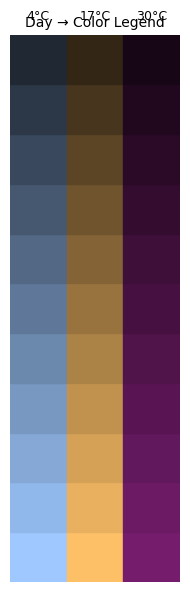

In [13]:
# # Rebuild the gradient palette dictionary manually since the file is missing

# # gradient_palette = {
# #     '4°C (Sky Blue)': {
# #         '1': '#22485d', '2': '#28536b', '3': '#2d5e79', '4': '#326887', '5': '#377395',
# #         '6': '#3c7ea3', '7': '#4189b1', '10': '#4794bf', '14': '#4c9ecd', '21': '#51a9db', '28': '#56b4e9'
# #     },
# #     '17°C (Bluish Green)': {
# #         '1': '#003f2e', '2': '#004935', '3': '#00523c', '4': '#005c43', '5': '#00654a',
# #         '6': '#006f50', '7': '#007857', '10': '#00825e', '14': '#008b65', '21': '#00956c', '28': '#009e73'
# #     },
# #     '30°C (Orange)': {
# #         '1': '#5c4000', '2': '#6a4900', '3': '#785300', '4': '#855c00', '5': '#936600',
# #         '6': '#a16f00', '7': '#af7900', '10': '#bd8200', '14': '#ca8c00', '21': '#d89500', '28': '#e69f00'
# #     }
# # }
# gradient_palette = gradient_palette_adjusted.copy()


# # Use previously defined metadata generation and plotting
# # Define temperature groups and days
# temps = ['4°C (Sky Blue)', '17°C (Bluish Green)', '30°C (Orange)']
# days_ordered = ['1', '2', '3', '4', '5', '6', '7', '10', '14', '21', '28']



# metadata = md.copy()

# # Map numerical temperature strings to gradient_palette keys
# temp_key_map = {
#     '4': '4°C (Sky Blue)',
#     '17': '17°C (Bluish Green)',
#     '30': '30°C (Orange)'
# }


# # Assign color
# def map_color(row):
#     day = str(row['day'])
#     temp_raw = str(row['temperature'])
    
#     if row.get('control', False) or temp_raw == '20' or day == '0':
#         return '#000000'  # Black for control

#     temp = temp_key_map.get(temp_raw)
#     if temp and day in gradient_palette[temp]:
#         return gradient_palette[temp][day]
    
#     return '#BBBBBB'  # Fallback


# metadata['color'] = metadata.apply(map_color, axis=1)

# # Create a legend for the color gradients
# fig_leg, ax_leg = plt.subplots(figsize=(2, 6))

# # Plot vertical gradients for each temperature
# for col, temp in enumerate(temps):
#     for row, day in enumerate(reversed(days_ordered)):
#         color = gradient_palette[temp][day]
#         ax_leg.add_patch(plt.Rectangle((col, row), 1, 1, color=color))
#     ax_leg.text(col + 0.5, len(days_ordered) + 0.3, temp.split()[0], ha='center', fontsize=9)

# ax_leg.set_xlim(0, 3)
# ax_leg.set_ylim(0, len(days_ordered))
# ax_leg.set_xticks([])
# ax_leg.set_yticks([])
# ax_leg.set_title("Day → Color Legend", fontsize=10)
# ax_leg.axis('off')

# plt.tight_layout()
# plt.show()


In [14]:
# #make a new color column where all colors are the same per temperature (the brightes of the previous colors, except for 20 degrees it is black):
# # Define the new color mapping
# def map_color_fixed(row):
#     temp_raw = str(row['temperature'])
    
#     if row.get('control', False) or temp_raw == '20' or row['day'] == '0':
#         return '#000000'  # Black for control

#     temp = temp_key_map.get(temp_raw)
#     if temp:
#         return gradient_palette[temp]['28']  # Use the color for day 28
    
#     return '#BBBBBB'  # Fallback

In [15]:
# metadata['color2'] = metadata.apply(map_color_fixed, axis=1)

In [13]:
metadata = merged_df_4.copy()

In [14]:
md = metadata.copy()

Kruskal per time point:

In [123]:
# from scipy.stats import kruskal
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# def plot_alpha_diversity(data, value_col, title, ylabel, return_stats=False):
#     # Calculate means and stds
#     means = data.groupby(['day', 'temperature'])[value_col].mean().reset_index()
#     stds = data.groupby(['day', 'temperature'])[value_col].std().reset_index()
#     means = means.rename(columns={value_col: 'mean_value'})
#     stds = stds.rename(columns={value_col: 'std_value'})
    
#     summary_df = pd.merge(means, stds, on=['day', 'temperature'])
#     summary_df['error'] = summary_df['std_value']
    
#     temperature_labels = {4: "4°C", 17: "17°C", 30: "30°C", 20: "Control"}
#     summary_df['temperature_label'] = summary_df['temperature'].map(temperature_labels)

#     # Plot
#     plt.figure(figsize=(8, 4))
#     ax = sns.lineplot(
#         data=summary_df,
#         x='day', y='mean_value', hue='temperature_label',
#         palette=custom_palette, marker="o", ci=None
#     )

#     # Error bars
#     for _, row in summary_df.iterrows():
#         plt.errorbar(
#             row['day'], row['mean_value'], 
#             yerr=row['error'], fmt='none', 
#             color=custom_palette[row['temperature_label']],
#             alpha=0.7, capsize=5, elinewidth=1
#         )

#     # Kruskal–Wallis tests
#     stats_list = []
#     data = data.copy()
#     data = data[data['temperature'].isin([4, 17, 30])]  # Remove control
#     grouped = data.groupby('day')

#     y_range = data[value_col].max() - data[value_col].min()

#     for day, group in grouped:
#         row = {'day': day, 'n_temperatures': group['temperature'].nunique()}
#         if group['temperature'].nunique() >= 2:
#             groups = [
#                 group[group['temperature'] == t][value_col].dropna()
#                 for t in [4, 17, 30] if t in group['temperature'].values
#             ]
#             stat, p = kruskal(*groups)
#             row['kruskal_stat'] = stat
#             row['p_value'] = p
#             if p < 0.05:
#                 max_y = group[value_col].max()
#                 if p < 0.001:
#                     stars = '***'
#                 elif p < 0.01:
#                     stars = '**'
#                 else:
#                     stars = '*'
#                 ax.text(day, max_y + 0.001 * y_range, stars, ha='center', va='bottom', fontsize=14)
#         else:
#             row['kruskal_stat'] = None
#             row['p_value'] = None
#         stats_list.append(row)

#     stats_df = pd.DataFrame(stats_list)

#     # Final touches
#     plt.title(title, fontsize=14)
#     plt.xlabel('Days', fontsize=12)
#     plt.ylabel(ylabel, fontsize=12)
#     desired_days = [1, 2, 3, 4, 5, 6, 7, 10, 14, 21, 28]
#     plt.xticks(ticks=desired_days, labels=desired_days, fontsize=12)
#     plt.yticks(fontsize=12)

#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     plt.grid(False)

#     legend = plt.legend(title='Temperature', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=12)
#     legend.set_title('')
#     fig = plt.gcf()  # <-- Add this at the end of the function before `plt.show()`
#     plt.tight_layout()
#     plt.show()

#     if return_stats:
#         return fig, stats_df




In [121]:
! pip install xlsxwriter

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_59021/3963773602.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

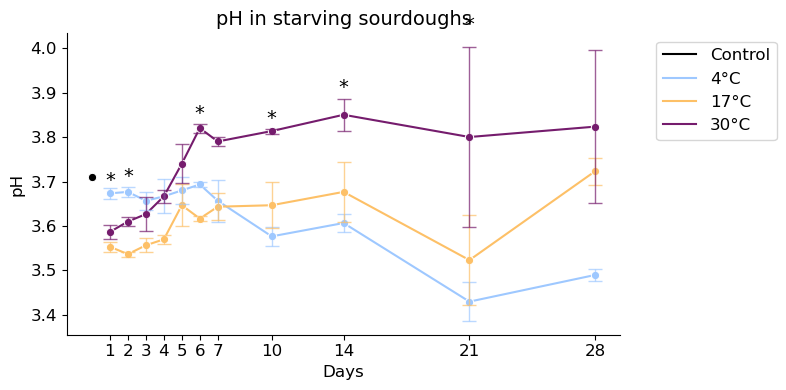

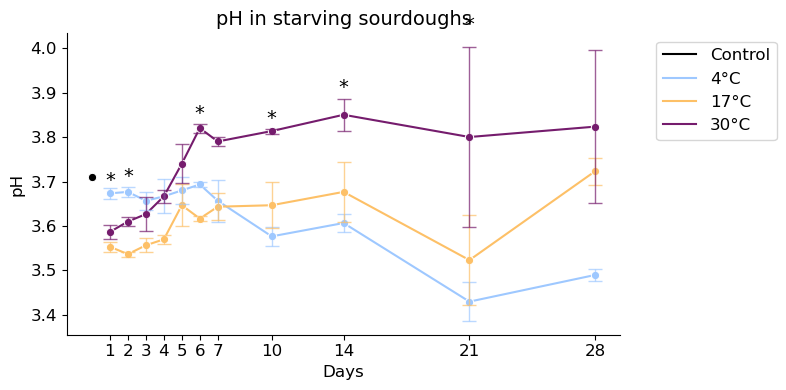

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_59021/3963773602.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

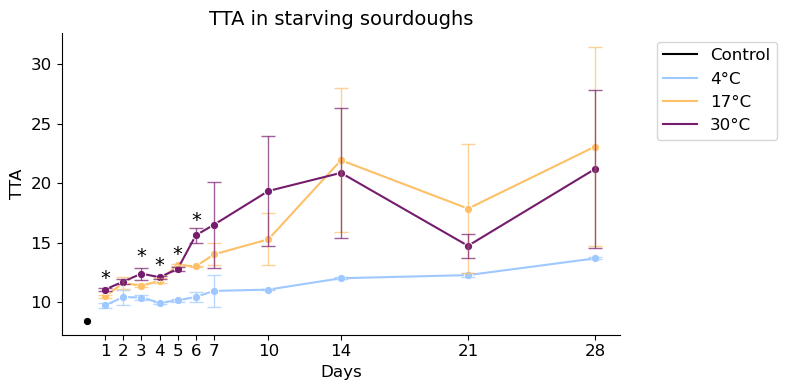

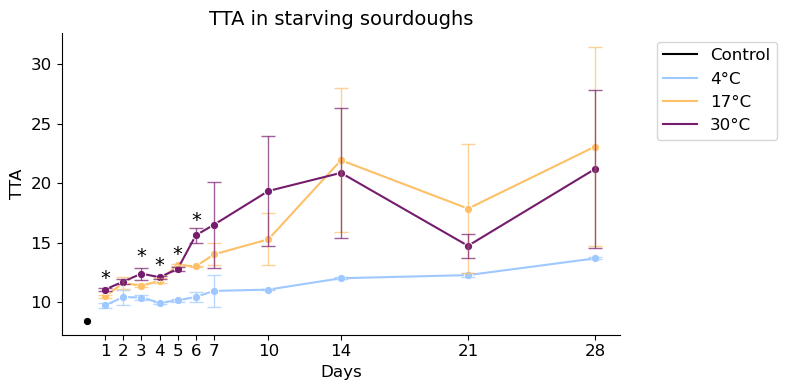

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_59021/3963773602.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

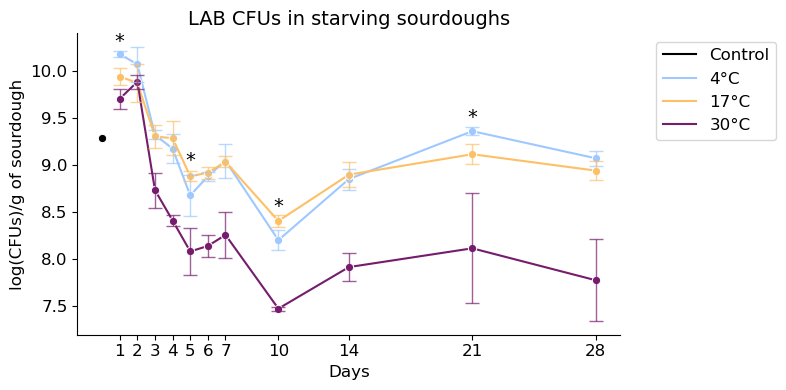

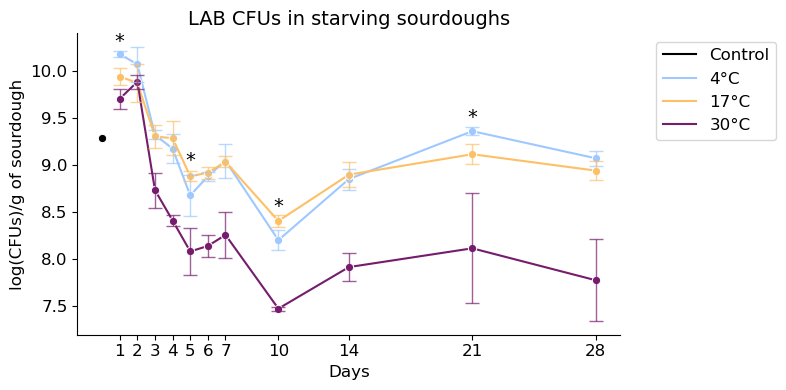

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_59021/3963773602.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

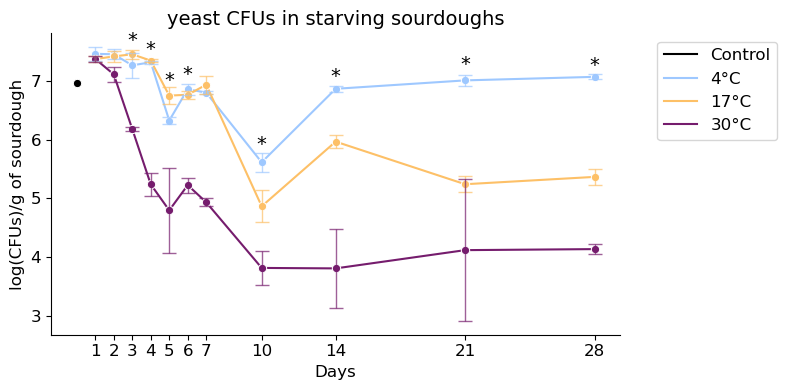

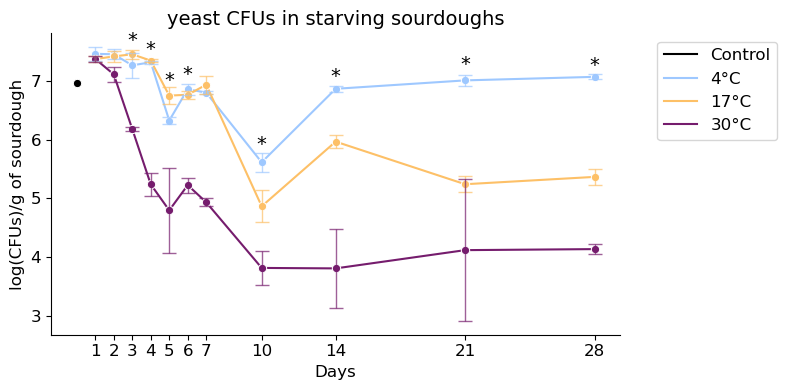

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_59021/3963773602.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

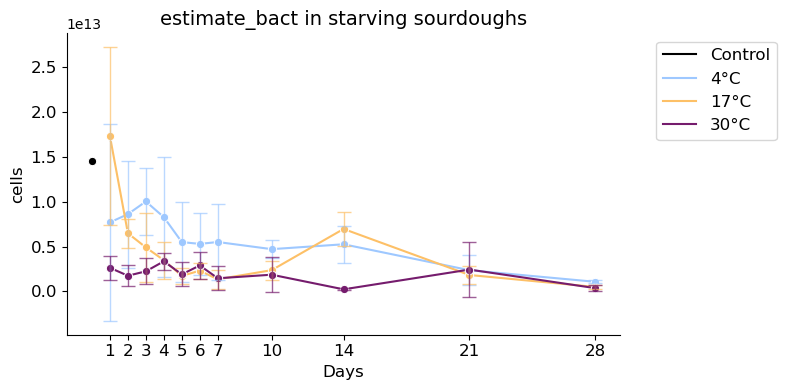

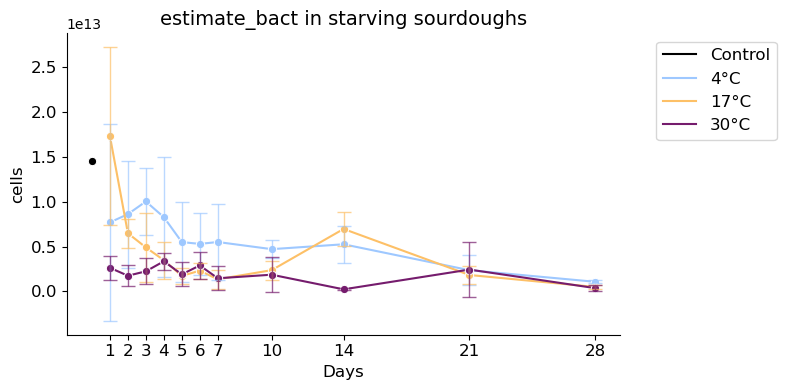

All results saved to: Stats/20250512_kruskal_results_all_metrics_ASVs_merged.xlsx


In [124]:
# import os
# import pandas as pd
# import matplotlib.pyplot as plt
# from IPython.display import display
# from scipy.stats import kruskal
# import xlsxwriter

# # Output paths
# fig_dir = "Figures/per_variable_stats_kruskal/"
# os.makedirs(fig_dir, exist_ok=True)
# excel_path = "Stats/20250512_kruskal_results_all_metrics_ASVs_merged.xlsx"

# # Variables to loop over
# metrics = {
#     'pH': 'pH',
#     'TTA': 'TTA',
#     'LAB CFUs': 'log(CFUs)/g of sourdough',
#     'yeast CFUs': 'log(CFUs)/g of sourdough',
#     'estimate_bact': 'cells'
# }

# # Container for all results (for Excel export)
# excel_writer = pd.ExcelWriter(excel_path, engine='xlsxwriter')

# for var, ylab in metrics.items():
#     title = f"{var} in starving sourdoughs"
#     filename = os.path.join(fig_dir, f"20250512_Kruskal_{var.replace(' ', '_')}.pdf")

#     # Get plot and stats
#     fig, result_df = plot_alpha_diversity(
#         data=md,
#         value_col=var,
#         title=title,
#         ylabel=ylab,
#         return_stats=True
#     )

#     # Save and show
#     fig.savefig(filename, format='pdf', bbox_inches='tight')
#     display(fig)
#     plt.close(fig)

#     # Save stats
#     result_df.to_excel(excel_writer, sheet_name=var[:31], index=False)


# # Save the Excel workbook
# excel_writer.close()
# print(f"All results saved to: {excel_path}")


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_59021/2632786841.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

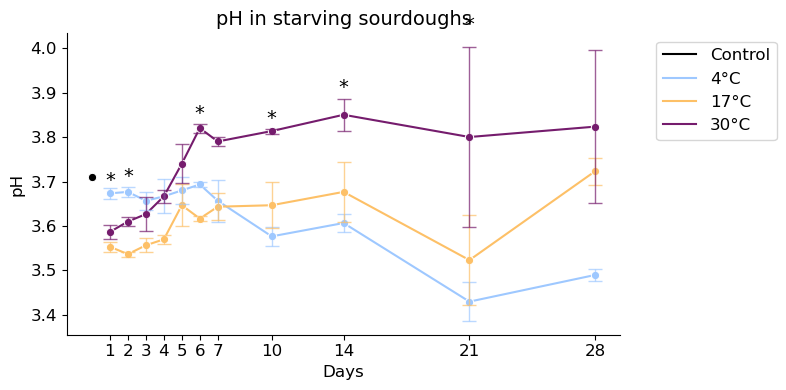

    day   p_value
0     1  0.025706
1     2  0.025706
2     3  0.050906
3     4  0.062818
4     5  0.062818
5     6  0.025706
6     7  0.066463
7    10  0.037942
8    14  0.038990
9    21  0.038990
10   28  0.119433


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_59021/2632786841.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

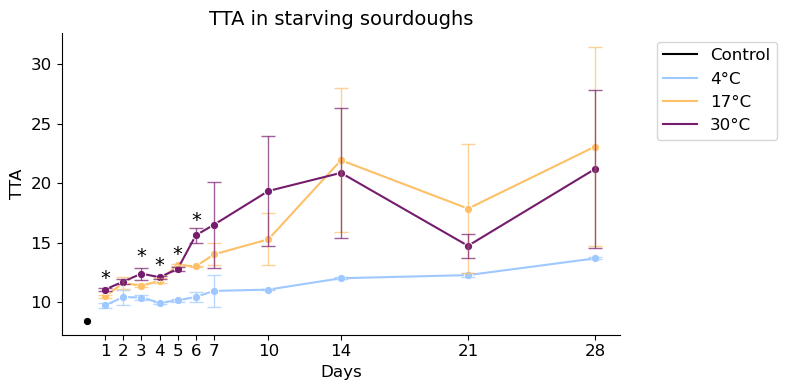

    day   p_value
0     1  0.027324
1     2  0.065698
2     3  0.027324
3     4  0.038990
4     5  0.027324
5     6  0.027324
6     7  0.050906
7    10  0.050906
8    14  0.060810
9    21  0.060810
10   28  0.133469


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_59021/2632786841.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

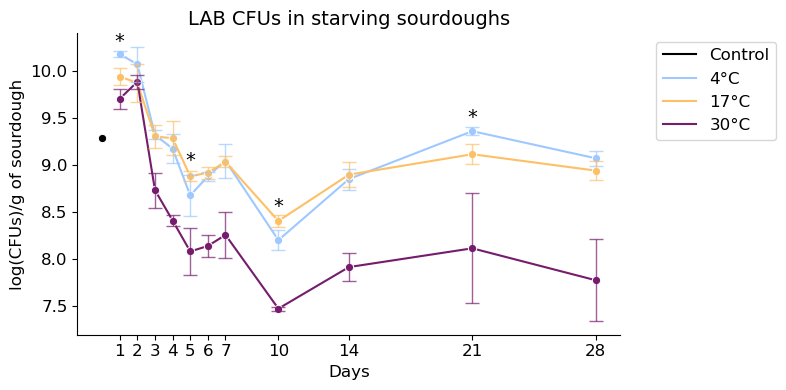

    day   p_value
0     1  0.027324
1     2  0.429796
2     3  0.060810
3     4  0.050906
4     5  0.027324
5     6  0.060810
6     7  0.066463
7    10  0.027324
8    14  0.050906
9    21  0.027324
10   28  0.062177


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_59021/2632786841.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

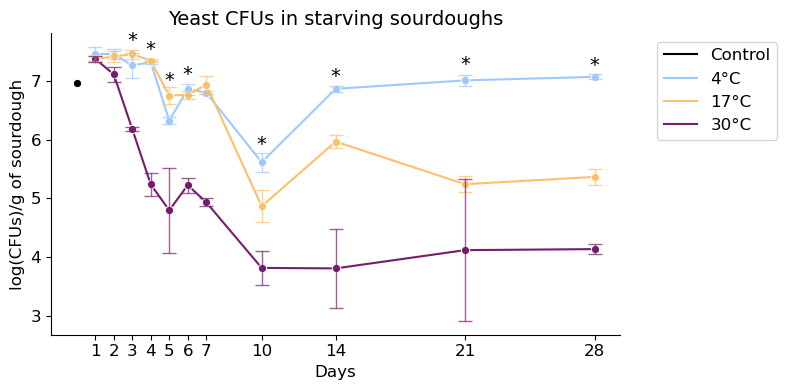

    day   p_value
0     1  0.561144
1     2  0.066463
2     3  0.038990
3     4  0.036904
4     5  0.027324
5     6  0.038990
6     7  0.060810
7    10  0.027324
8    14  0.027324
9    21  0.038990
10   28  0.043937


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_59021/2632786841.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

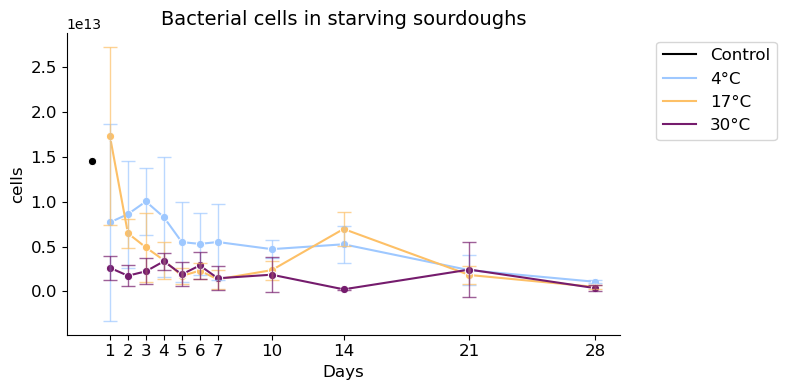

    day   p_value
0     1  0.193120
1     2  0.065698
2     3  0.147916
3     4  0.732632
4     5  0.732632
5     6  0.586646
6     7  0.429796
7    10  0.060810
8    14  0.050906
9    21  0.956529
10   28  0.133469


In [108]:
# # To both plot and inspect significance:
# results_pH = plot_alpha_diversity(md, 'pH', 'pH in starving sourdoughs', 'pH', return_stats=True)

# # Check p-values
# print(results_pH[['day', 'p_value']])

# results_TTA = plot_alpha_diversity(md, 'TTA', 'TTA in starving sourdoughs', 'TTA', return_stats=True)

# # Check p-values
# print(results_TTA[['day', 'p_value']])

# results_LAB = plot_alpha_diversity(md, 'LAB CFUs', 'LAB CFUs in starving sourdoughs', 'log(CFUs)/g of sourdough', return_stats=True)
# # Check p-values
# print(results_LAB[['day', 'p_value']])
# results_yeast = plot_alpha_diversity(md, 'yeast CFUs', 'Yeast CFUs in starving sourdoughs', 'log(CFUs)/g of sourdough', return_stats=True)
# # Check p-values
# print(results_yeast[['day', 'p_value']])
# results_bact = plot_alpha_diversity(md, 'estimate_bact', 'Bacterial cells in starving sourdoughs', 'cells', return_stats=True)
# # Check p-values
# print(results_bact[['day', 'p_value']])
# # Save the results to a file
# # results_pH.to_csv('results_pH.csv', index=False)
# # results_TTA.to_csv('results_TTA.csv', index=False)
# # results_LAB.to_csv('results_LAB.csv', index=False)
# # results_yeast.to_csv('results_yeast.csv', index=False)
# # results_bact.to_csv('results_bact.csv', index=False)




## ANOVAs for all variables

In [18]:
# #save the metadata file with color scheme:
# #save the metadata as a csv file:
# metadata.to_csv('20250513_16S_shipping_general_metadata_all_samples_with_alpha_diversity_color_scheme.csv', sep=',')

In [15]:
md

,Chao1 kmers ITS,Chao1 OTUs ITS,Chao1 ASVs ITS,16S_id,Chao1 kmers,Chao1 OTUs,Chao1 ASVs,identifier,row,column,...,Observed features kmers ITS,Shannon ASVs ITS,Evenness ASVs ITS,Simpson ASVs ITS,Shannon OTUs ITS,Evenness OTUs ITS,Simpson OTUs ITS,Shannon kmers ITS,Evenness kmers ITS,Simpson kmers ITS
366292_209-LP4-ITS-0709,747.0,2.00,4.000000,366294_209-LP4-16S-0709,678.0,5.0,4.0,W00.00.00,E,5,...,747.0,1.023700,0.511850,0.387775,0.301049,0.301049,0.101261,8.420116,0.882153,0.996797
366292_121-LP4-ITS-0621,1052.0,4.00,6.000000,366294_121-LP4-16S-0621,244.0,1.0,1.0,W30.02.28,E,6,...,1052.0,0.973628,0.376651,0.377949,0.220637,0.110319,0.056100,8.340575,0.830824,0.996682
366292_212-LP4-ITS-0712,1253.0,7.50,7.000000,366294_212-LP4-16S-0712,718.0,5.0,6.0,W30.03.21,H,5,...,1253.0,0.813642,0.289825,0.337533,0.091995,0.032769,0.017630,8.253068,0.801956,0.996594
366292_225-LP4-ITS-0725,1212.0,5.00,7.000000,366294_225-LP4-16S-0725,708.0,6.0,5.0,W17.02.14,E,7,...,1212.0,0.800344,0.285088,0.338125,0.051600,0.022223,0.009683,8.229968,0.803459,0.996578
366292_201-LP4-ITS-0701,1204.0,5.00,8.000000,366294_201-LP4-16S-0701,708.0,5.0,5.0,W04.02.04,E,4,...,1204.0,1.144517,0.381506,0.390090,0.329954,0.142104,0.083077,8.529651,0.833493,0.996862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366292_181-LP4-ITS-0681,3357.0,23.50,26.428571,366294_181-LP4-16S-0681,708.0,5.0,5.0,W30.03.03,A,2,...,3357.0,1.155855,0.248900,0.388582,0.459375,0.103012,0.101151,8.474403,0.723507,0.996769
366292_251-LP4-ITS-0751,3265.0,16.25,34.000000,366294_251-LP4-16S-0751,708.0,5.0,8.0,W04.03.01,G,10,...,3265.0,1.052332,0.226607,0.377837,0.284167,0.071042,0.057944,8.393120,0.719028,0.996696
366292_260-LP4-ITS-0760,3137.0,23.50,32.000000,366294_260-LP4-16S-0760,708.0,5.0,5.0,W30.02.01,H,11,...,3137.0,1.222896,0.263336,0.410682,0.527800,0.116678,0.117316,8.511062,0.732754,0.996812
366292_264-LP4-ITS-0764,3434.0,30.20,25.375000,366294_264-LP4-16S-0764,708.0,5.0,5.0,W04.03.04,D,12,...,3434.0,1.233053,0.265523,0.405510,0.487944,0.103808,0.102250,8.521965,0.725541,0.996818


In [10]:
import pandas as pd
from scipy.stats import levene

# Assuming 'md' DataFrame is available and properly formatted
# Prepare to store Levene's test results
levene_results = []
# Variables to loop over
metrics = {
    # 'pH': ('pH', 28, 3.3, 4.2),
    # 'TTA': ('TTA', 28, 0, 33),
    # 'LAB CFUs': ('log(CFUs)/g of sourdough', 28, 7, 10.5),
    # 'yeast CFUs': ('log(CFUs)/g of sourdough', 28, 2.5, 8.5),
    # 'estimate_bact': ('bacterial cells', 28, 0, 2.5e13),
    # 'DNA yield': ('DNA yield (ng/μL)', 28, 0, 35),
    # 'acetic acid': ('Concentration (mM)', 21, 0, 700),
    # 'glucose': ('Concentration (g/L)', 21, 0, 0.7),
    # 'fructose': ('Concentration (g/L)', 21, 0, 0.1),
    # 'sucrose': ('Concentration (g/L)', 21, -0.01, 0.11),
    # 'maltose': ('Concentration (g/L)', 21, -1, 5.7),
    # 'succinic acid': ('Concentration (mM)', 21, 0, 55),
    # 'lactic acid': ('Concentration (mM)', 21, 0, 600),
    # 'ethanol': ('Concentration (mM)', 21, 0, 930),
    # 'mannitol': ('Concentration (g/L)', 21, 0, 2.1),
    # 'Chao1 kmers': ('Chao1 kmers', 28, 0, 800),
    # 'Chao1 OTUs': ('Chao1 OTUs', 28, 0, 11),
    # 'Chao1 ASVs': ('Chao1 ASVs', 28, 0, 11),
    'Observed features ASVs ITS': ('Observed features ASVs ITS', 28, 0, 8),
    'Observed features OTUs ITS': ('Observed features OTUs ITS', 28, 0, 8),
    'Observed features kmers ITS': ('Observed features kmers ITS', 28, 0, 800),
    'Evenness ASVs ITS': ('Evenness ASVs ITS', 28, 0, 1),
    'Evenness OTUs ITS': ('Evenness OTUs ITS', 28, 0, 1),
    'Evenness kmers ITS': ('Evenness kmers ITS', 28, 0.8, 1),
    'Shannon ASVs ITS': ('Shannon ASVs ITS', 28, 0, 2),
    'Shannon OTUs ITS': ('Shannon OTUs ITS', 28, 0, 2),
    'Shannon kmers ITS': ('Shannon kmers ITS', 28, 0.74, 9.5),
    # 'Simpson ASVs': ("Simpson's index (D) ASVs", 28, 0, 0.8),
    # 'Simpson OTUs': ("Simpson's index (D) OTUs", 28, 0, 0.8),
    # 'Simpson kmers': ("Simpson's index (D) kmers", 28, 0.995, 1)
}

for metric in metrics.keys():
    for day in sorted(md['day'].unique()):
        subset = md[(md['day'] == day) & (md['temperature'].isin([4, 17, 30]))]
        values = [subset[subset['temperature'] == t][metric].dropna() for t in [4, 17, 30]]
        
        # Only test if there are at least two groups with more than one value
        if sum(len(v) > 1 for v in values) >= 2:
            stat, p = levene(*values)
            levene_results.append({
                'variable': metric,
                'day': day,
                'Levene_p': p
            })

levene_df = pd.DataFrame(levene_results)

# Count percentages
total_tests = len(levene_df)
above_0_05 = (levene_df['Levene_p'] > 0.05).sum()
below_0_05 = total_tests - above_0_05
above_pct = round((above_0_05 / total_tests) * 100, 2)
below_pct = round((below_0_05 / total_tests) * 100, 2)

above_pct, below_pct

(100.0, 0.0)

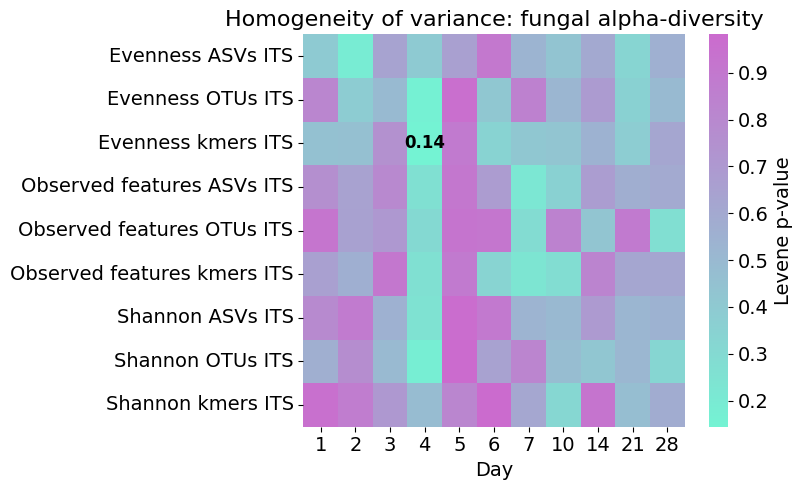

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Pivot for heatmap
heatmap_data = levene_df.pivot(index='variable', columns='day', values='Levene_p')

# Custom colormap
custom_cmap = LinearSegmentedColormap.from_list(
    name='custom_cmap',
    colors=["#74F3D3FF", "#CB6BCEFF"],
    N=256
)

# Plot heatmap
plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    heatmap_data,
    annot=False,
    fmt=".2f",
    cmap=custom_cmap,
    cbar_kws={'label': 'Levene p-value'}
)

# Title and axis labels
plt.title("Homogeneity of variance: fungal alpha-diversity", fontsize=16)
plt.xlabel("Day", fontsize=14)
plt.ylabel("", fontsize=14)
ax.tick_params(labelsize=14)

# Customize color bar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # Tick label size
cbar.ax.set_ylabel("Levene p-value", fontsize=14)  # Label size

# Add stars for significance
# for y, row_label in enumerate(heatmap_data.index):
#     for x, col_label in enumerate(heatmap_data.columns):
#         pval = heatmap_data.loc[row_label, col_label]
#         if pval < 0.1:
#             ax.text(
#                 x + 0.5, y + 0.5, '*',
#                 ha='center', va='center',
#                 color='black', fontsize=16, fontweight='bold'
#             )
#Add stars for significance
for y, row_label in enumerate(heatmap_data.index):
    for x, col_label in enumerate(heatmap_data.columns):
        pval = heatmap_data.loc[row_label, col_label]
        if pval < 0.15:
            ax.text(
            x + 0.5, y + 0.5,
            f"{pval:.2f}",  # format with two decimal places inside parentheses
            ha='center', va='center',
            color='black', fontsize=12, fontweight='bold'
        )


plt.tight_layout()
plt.savefig('Figures/per_variable_stats_anova/20250725_ITS_shipping_Levene_test_alpha_diversity.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [18]:
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_alpha_diversity(data, value_col, title, ylabel, return_stats=False, max_day=None):
    data = data.copy()

    # Clean values
    data[value_col] = pd.to_numeric(data[value_col], errors='coerce')

    # Filter by max_day if specified
    if max_day is not None:
        data = data[data['day'] <= max_day]

    # Step 1: Mean & SD per temperature x day
    means = data.groupby(['day', 'temperature'])[value_col].mean().reset_index()
    stds = data.groupby(['day', 'temperature'])[value_col].std().reset_index()
    means = means.rename(columns={value_col: 'mean_value'})
    stds = stds.rename(columns={value_col: 'std_value'})
    summary_df = pd.merge(means, stds, on=['day', 'temperature'])
    summary_df['error'] = summary_df['std_value']

    # Temperature label mapping
    temperature_labels = {4: "4°C", 17: "17°C", 30: "30°C", 20: "Control"}
    summary_df['temperature_label'] = summary_df['temperature'].map(temperature_labels)
    # Rebuild custom_palette using labeled keys
    custom_palette = (
        md.drop_duplicates('temperature')
        .assign(temp_label=lambda df: df['temperature'].map(temperature_labels))
        .set_index('temp_label')['color2']
        .to_dict()
    )

    # Plotting
    plt.figure(figsize=(8, 4))
    ax = sns.lineplot(
        data=summary_df,
        x='day', y='mean_value', hue='temperature_label',
        palette=custom_palette, marker="o", ci=None
    )

    # Error bars
    for _, row in summary_df.iterrows():
        plt.errorbar(
            row['day'], row['mean_value'],
            yerr=row['error'], fmt='none',
            color=custom_palette[row['temperature_label']],
            alpha=0.7, capsize=5, elinewidth=1
        )

    # ANOVA tests
    stats_list = []
    data_filtered = data[data['temperature'].isin([4, 17, 30])]  # Exclude control
    grouped = data_filtered.groupby('day')
    y_range = data_filtered[value_col].max() - data_filtered[value_col].min()

    for day, group in grouped:
        row = {'day': day, 'n_temperatures': group['temperature'].nunique()}
        if row['n_temperatures'] >= 2:
            groups = [
                group[group['temperature'] == t][value_col].dropna()
                for t in [4, 17, 30] if t in group['temperature'].values
            ]
            if all(len(g) > 1 for g in groups):  # Avoid errors from singleton groups
                stat, p = f_oneway(*groups)
                # Rough eta-squared effect size: SSB / SST
                group_means = [g.mean() for g in groups]
                group_sizes = [len(g) for g in groups]
                overall_mean = group[value_col].mean()

                ss_between = sum(n * (mean - overall_mean)**2 for n, mean in zip(group_sizes, group_means))
                ss_total = sum((x - overall_mean)**2 for g in groups for x in g)
                eta_squared = ss_between / ss_total if ss_total > 0 else None
                row['effect_size_eta2'] = eta_squared

                row['anova_stat'] = stat
                row['p_value'] = p
                #also the means:
                row['mean'] = group_means
                #also save the standard deviation per group:
                row['std'] = [g.std() for g in groups]
            #     if p < 0.05:
            #         max_y = group[value_col].max()
            #         if p < 0.001:
            #             stars = '***'
            #         elif p < 0.01:
            #             stars = '**'
            #         else:
            #             stars = '*'
            #         ax.text(day, max_y + 0.05 * y_range, stars, ha='center', va='bottom', fontsize=14)
            # else:
                row['anova_stat'] = None
                row['p_value'] = None
        else:
            row['anova_stat'] = None
            row['p_value'] = None
        stats_list.append(row)

    stats_df = pd.DataFrame(stats_list)
    from statsmodels.stats.multitest import multipletests

    # Apply FDR correction only if there are p-values to correct
    valid_pvals = stats_df['p_value'].dropna()
    if len(valid_pvals) > 0:
        rejected, pvals_adj, _, _ = multipletests(valid_pvals, alpha=0.05, method='fdr_bh')

        # Store adjusted p-values and significance
        stats_df.loc[stats_df['p_value'].notna(), 'p_value_adj'] = pvals_adj
        stats_df.loc[stats_df['p_value'].notna(), 'significant'] = rejected

        # Re-annotate stars based on adjusted p-values
        for _, row in stats_df.dropna(subset=['p_value_adj']).iterrows():
            if row['significant']:
                p = row['p_value_adj']
                if p < 0.001:
                    stars = '***'
                elif p < 0.01:
                    stars = '**'
                else:
                    stars = '*'
                max_y = data[data['day'] == row['day']][value_col].max()
                ax.text(row['day'], max_y + 0.05 * y_range, stars, ha='center', va='bottom', fontsize=18)


    # Final plot styling
    plt.title(title, fontsize=16)
    plt.xlabel('Days', fontsize=16)
    plt.ylabel(ylabel, fontsize=16)
    # desired_days = [1, 2, 3, 4, 5, 6, 7, 10, 14, 21, 28]
    desired_days = sorted(data['day'].unique())

    plt.xticks(ticks=desired_days, labels=desired_days, fontsize=16)
    plt.yticks(fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.grid(False)
    legend = plt.legend(title='Temperature', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=16)
    legend.set_title('')
    fig = plt.gcf()
    plt.tight_layout()
    plt.show()

    if return_stats:
        return fig, stats_df



In [12]:
md['temperature'].unique()

array([20, 30, 17,  4])

In [13]:
#drop the temperature '20':

md = md[md['temperature'] != 20]
md


,Chao1 kmers ITS,Chao1 OTUs ITS,Chao1 ASVs ITS,16S_id,Chao1 kmers,Chao1 OTUs,Chao1 ASVs,identifier,row,column,...,Observed features kmers ITS,Shannon ASVs ITS,Evenness ASVs ITS,Simpson ASVs ITS,Shannon OTUs ITS,Evenness OTUs ITS,Simpson OTUs ITS,Shannon kmers ITS,Evenness kmers ITS,Simpson kmers ITS
366292_121-LP4-ITS-0621,1052.0,4.00,6.000000,366294_121-LP4-16S-0621,244.0,1.0,1.0,W30.02.28,E,6,...,1052.0,0.973628,0.376651,0.377949,0.220637,0.110319,0.056100,8.340575,0.830824,0.996682
366292_212-LP4-ITS-0712,1253.0,7.50,7.000000,366294_212-LP4-16S-0712,718.0,5.0,6.0,W30.03.21,H,5,...,1253.0,0.813642,0.289825,0.337533,0.091995,0.032769,0.017630,8.253068,0.801956,0.996594
366292_225-LP4-ITS-0725,1212.0,5.00,7.000000,366294_225-LP4-16S-0725,708.0,6.0,5.0,W17.02.14,E,7,...,1212.0,0.800344,0.285088,0.338125,0.051600,0.022223,0.009683,8.229968,0.803459,0.996578
366292_201-LP4-ITS-0701,1204.0,5.00,8.000000,366294_201-LP4-16S-0701,708.0,5.0,5.0,W04.02.04,E,4,...,1204.0,1.144517,0.381506,0.390090,0.329954,0.142104,0.083077,8.529651,0.833493,0.996862
366292_217-LP4-ITS-0717,1204.0,5.00,8.000000,366294_217-LP4-16S-0717,588.0,3.0,3.0,W04.02.01,E,6,...,1204.0,1.139327,0.379776,0.414038,0.249389,0.107406,0.058532,8.480431,0.828683,0.996810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366292_181-LP4-ITS-0681,3357.0,23.50,26.428571,366294_181-LP4-16S-0681,708.0,5.0,5.0,W30.03.03,A,2,...,3357.0,1.155855,0.248900,0.388582,0.459375,0.103012,0.101151,8.474403,0.723507,0.996769
366292_251-LP4-ITS-0751,3265.0,16.25,34.000000,366294_251-LP4-16S-0751,708.0,5.0,8.0,W04.03.01,G,10,...,3265.0,1.052332,0.226607,0.377837,0.284167,0.071042,0.057944,8.393120,0.719028,0.996696
366292_260-LP4-ITS-0760,3137.0,23.50,32.000000,366294_260-LP4-16S-0760,708.0,5.0,5.0,W30.02.01,H,11,...,3137.0,1.222896,0.263336,0.410682,0.527800,0.116678,0.117316,8.511062,0.732754,0.996812
366292_264-LP4-ITS-0764,3434.0,30.20,25.375000,366294_264-LP4-16S-0764,708.0,5.0,5.0,W04.03.04,D,12,...,3434.0,1.233053,0.265523,0.405510,0.487944,0.103808,0.102250,8.521965,0.725541,0.996818


In [16]:
md['temperature'].unique()

array([20, 30, 17,  4])

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

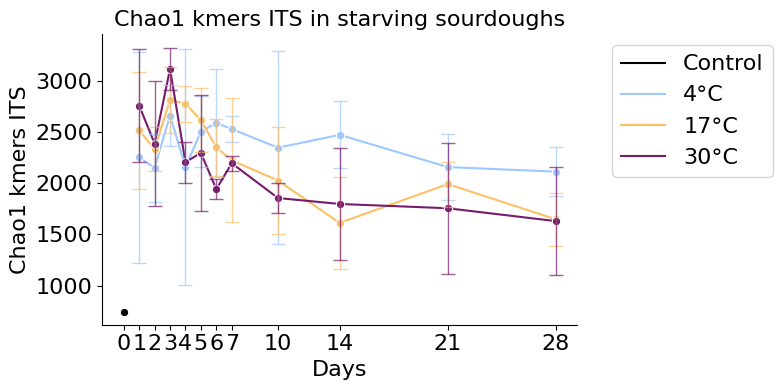

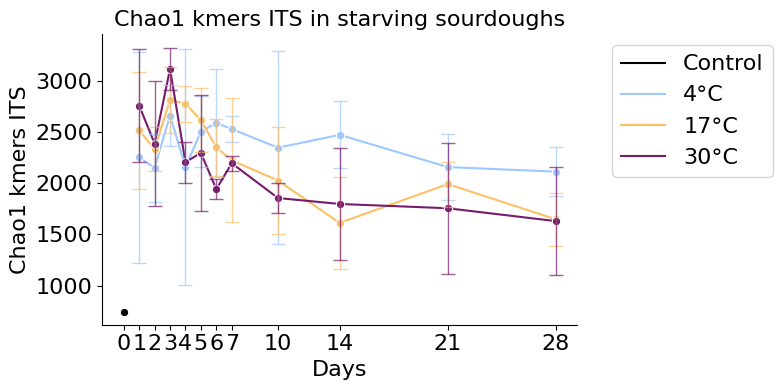

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

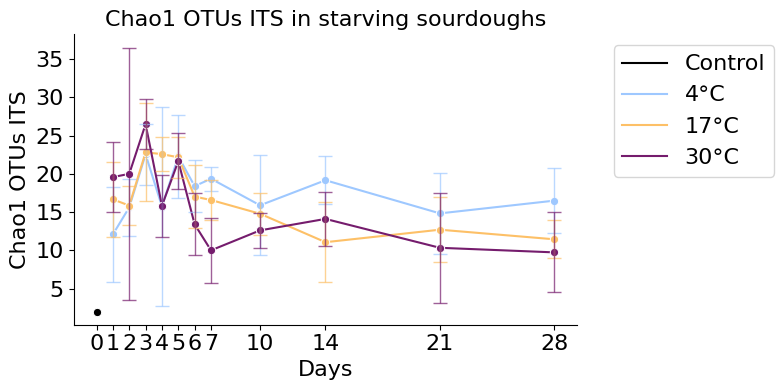

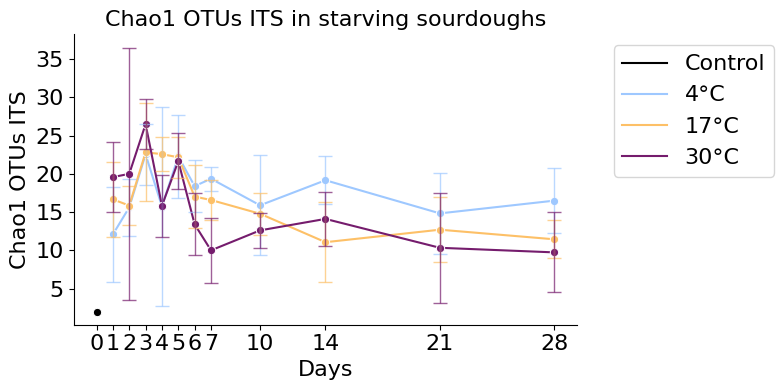

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

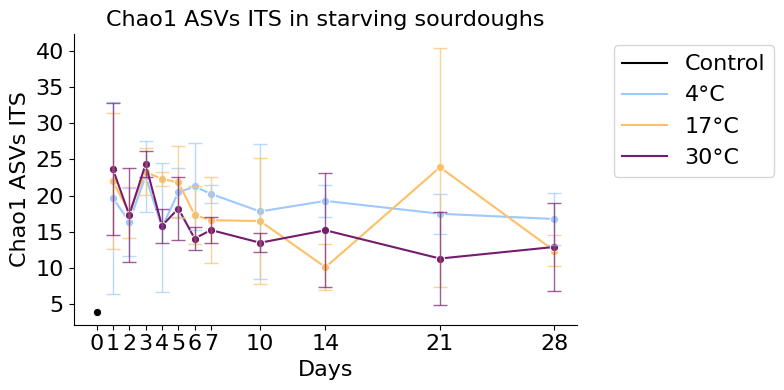

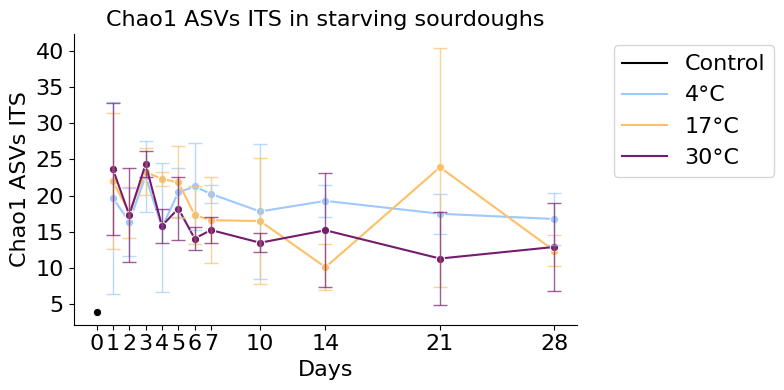

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

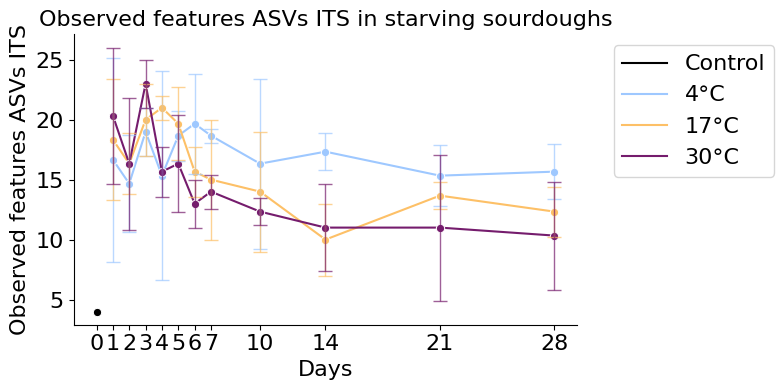

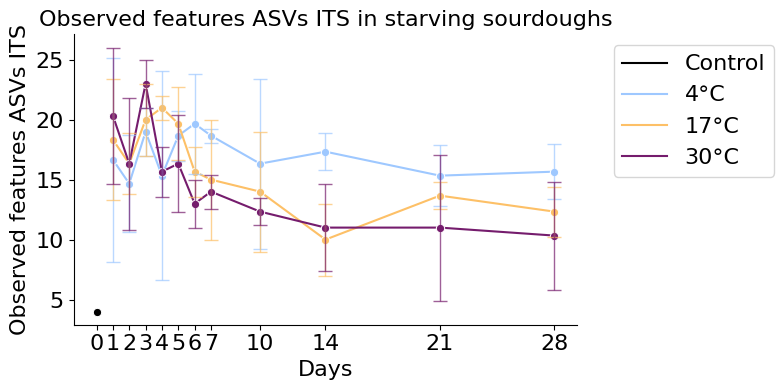

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

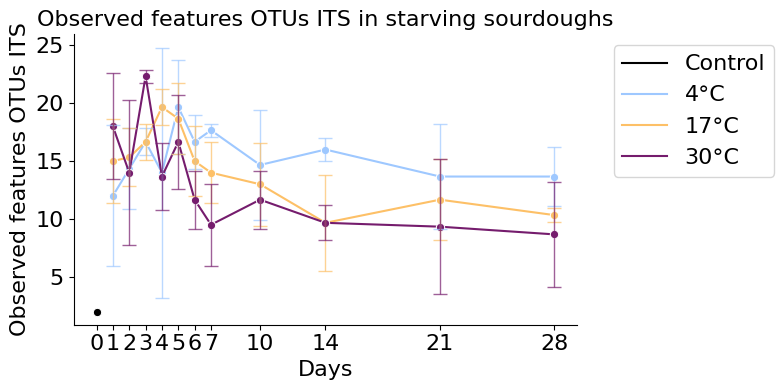

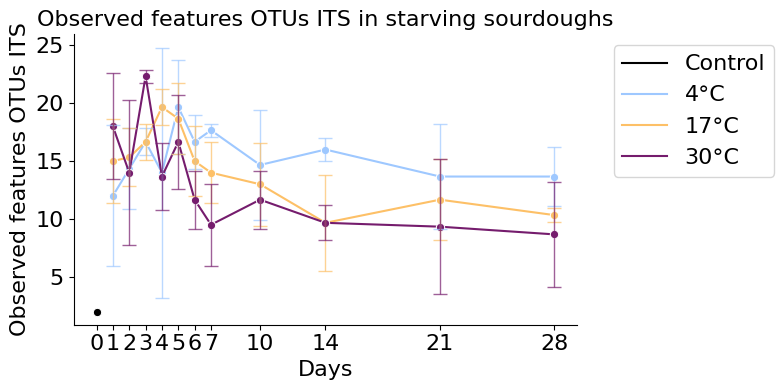

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

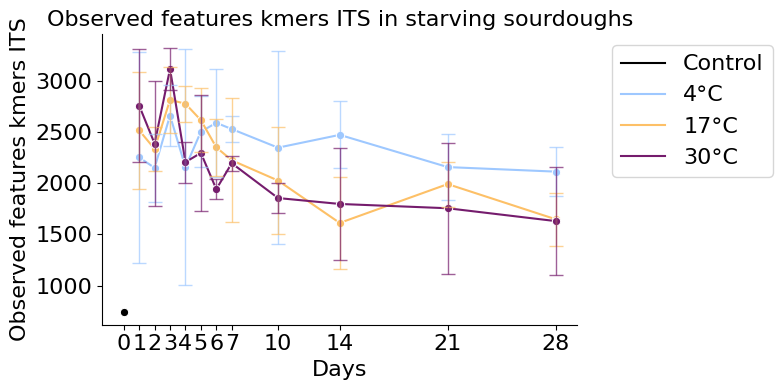

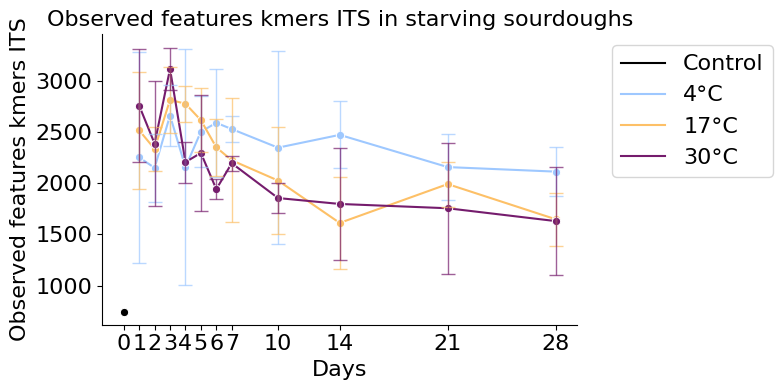

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

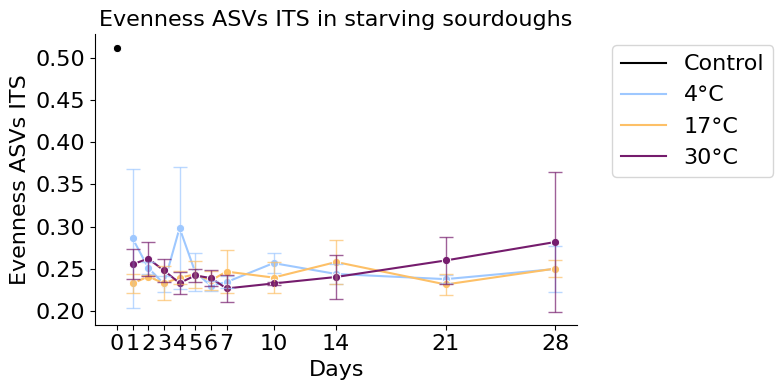

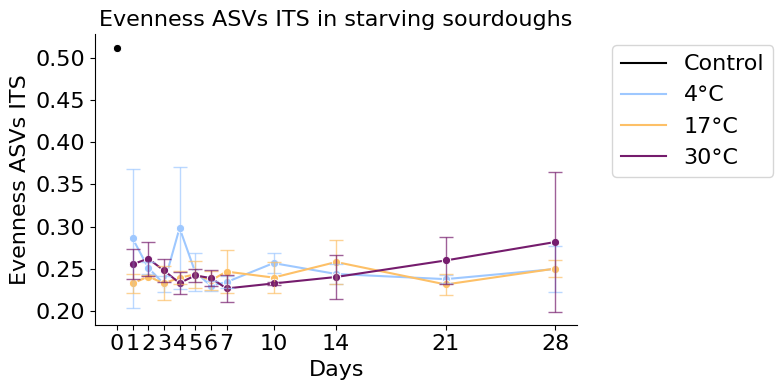

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

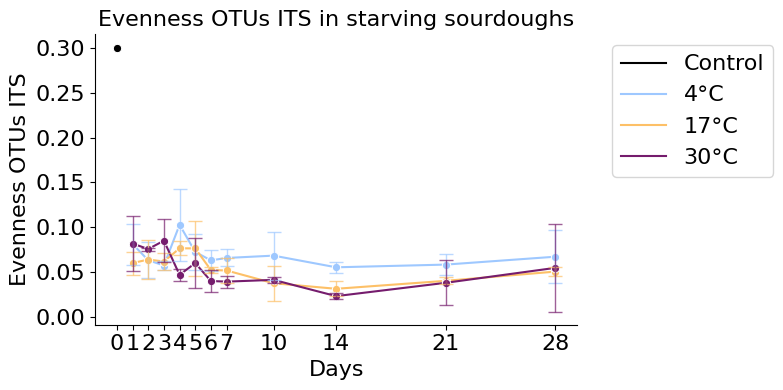

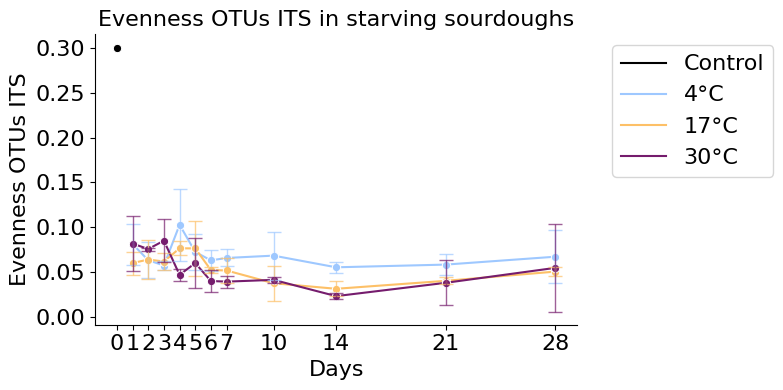

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

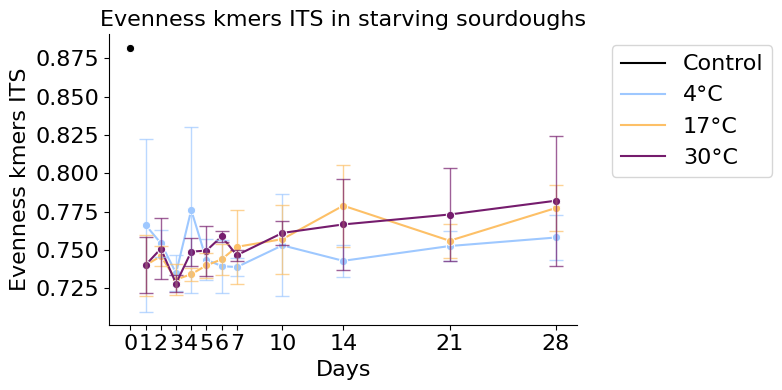

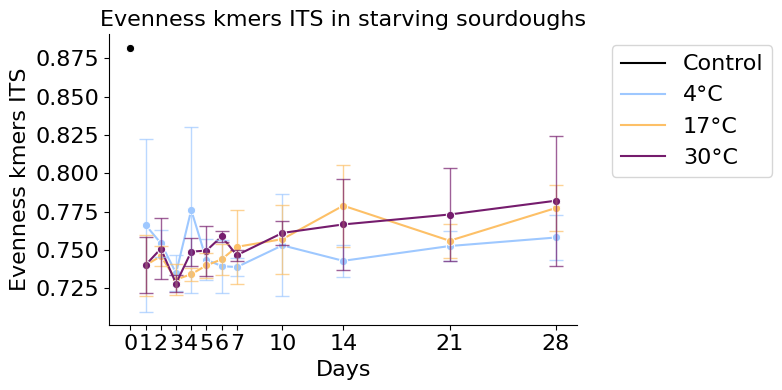

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

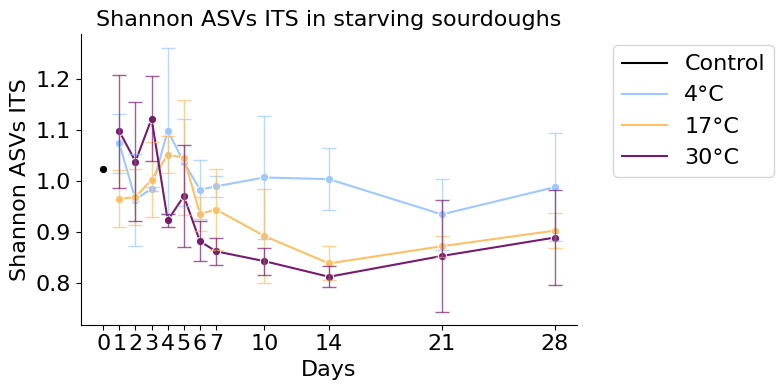

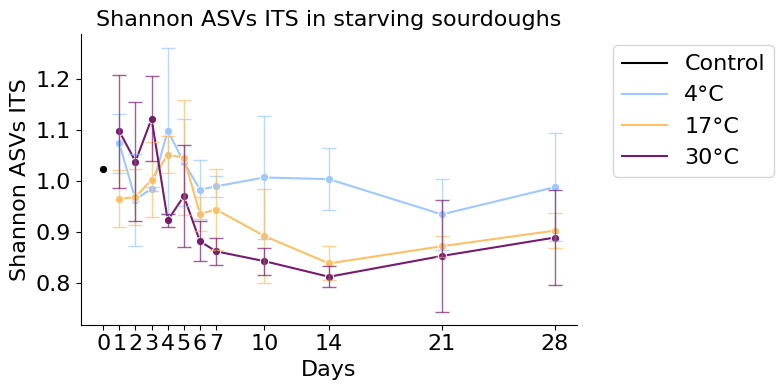

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

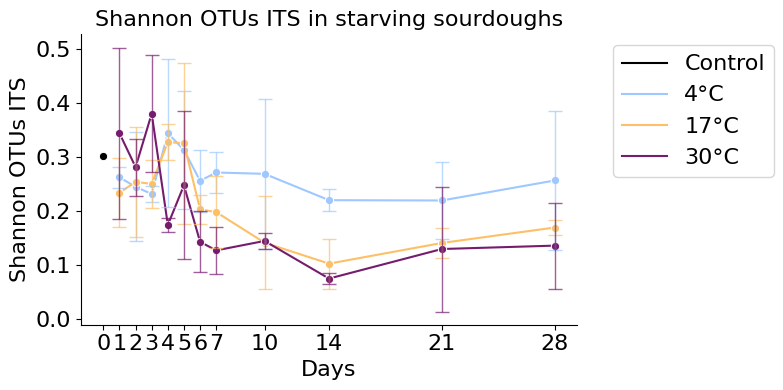

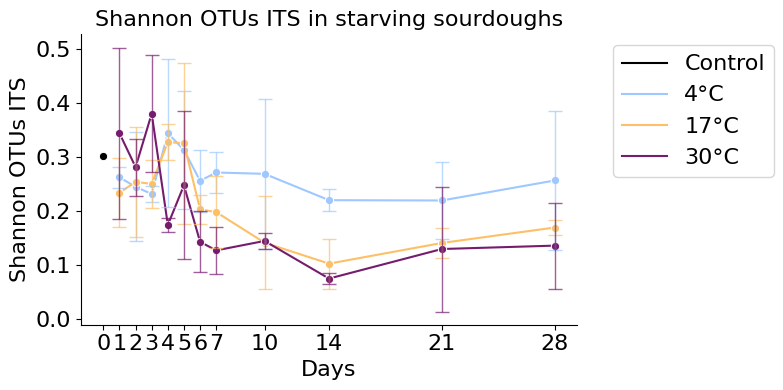

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

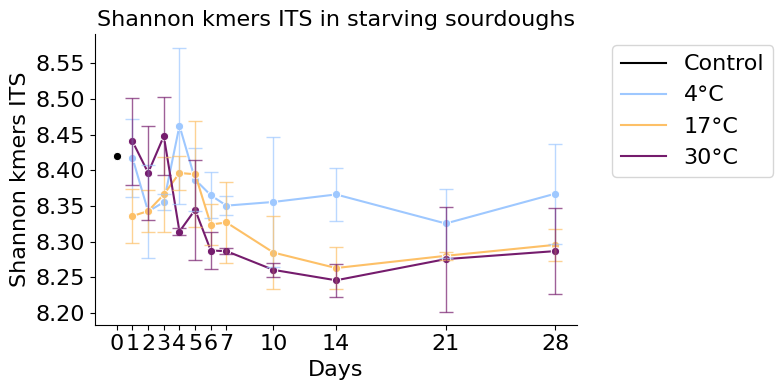

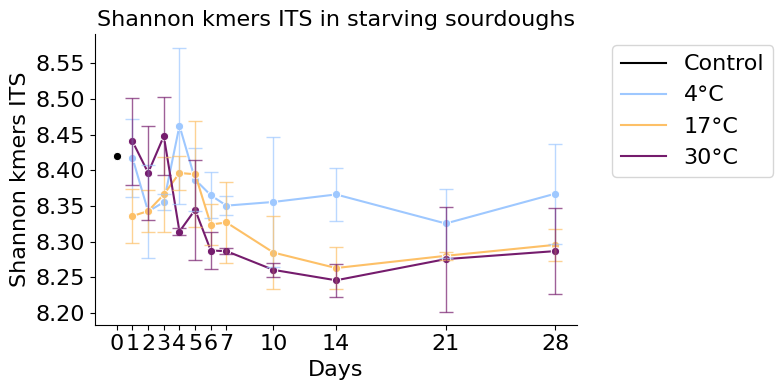

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

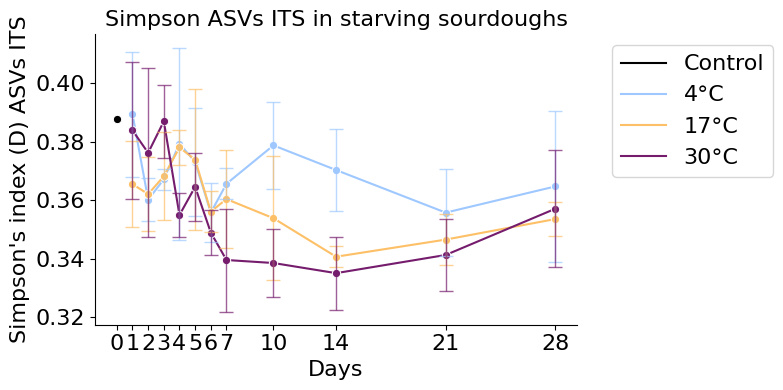

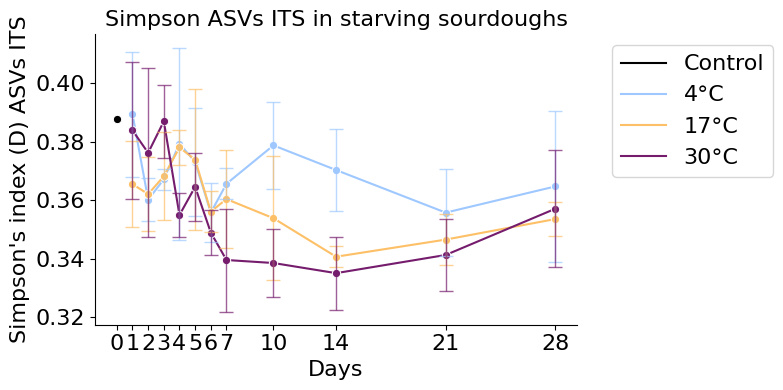

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

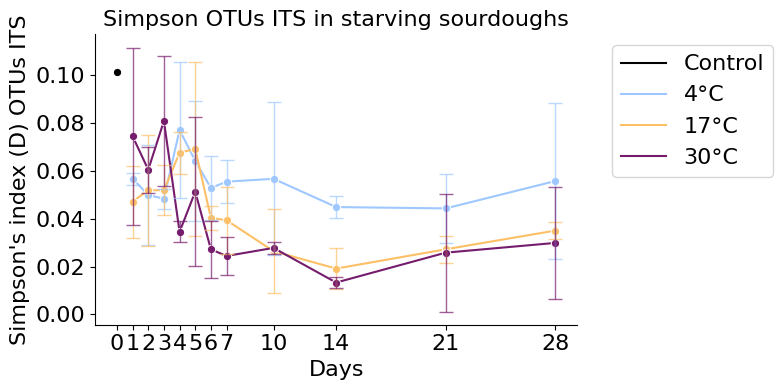

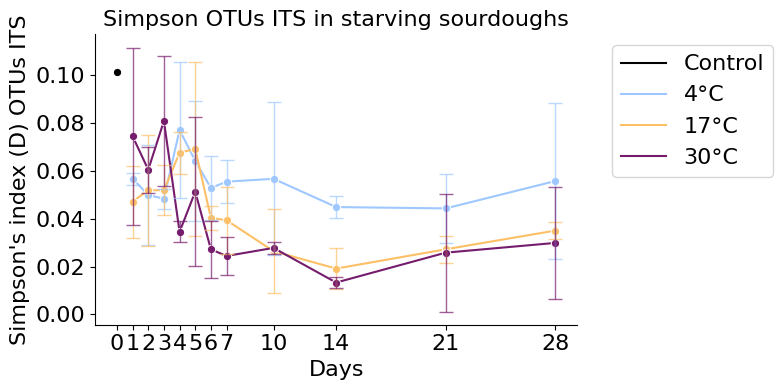

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_34624/1699634911.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pas

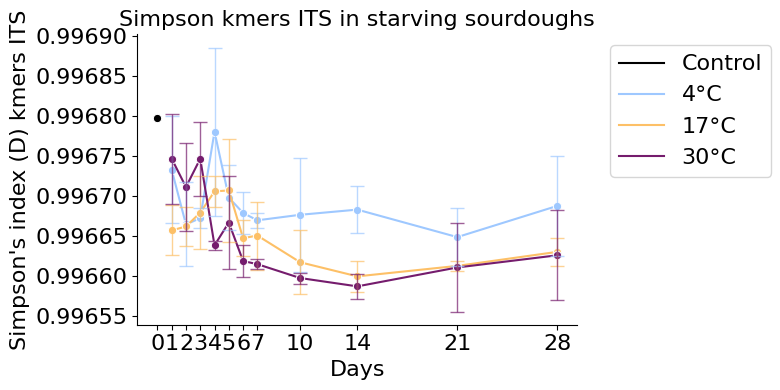

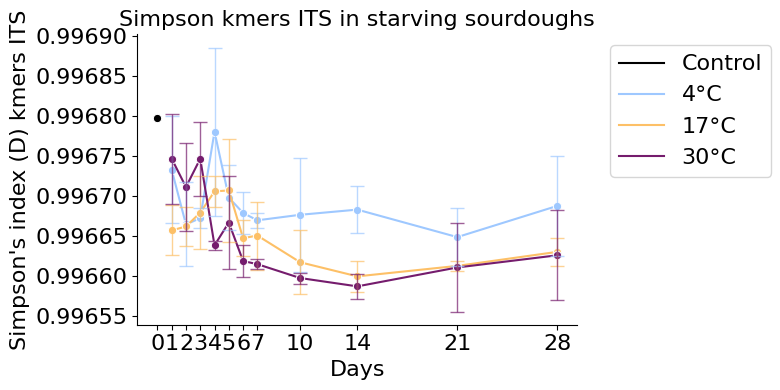

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import xlsxwriter

# Output paths
fig_dir = "Figures/per_variable_stats_anova/"
os.makedirs(fig_dir, exist_ok=True)
excel_path = "Stats/20251210_anova_results_all_metrics_ITS_merged.xlsx"

# Variables to loop over
metrics = {
    # 'pH': ('pH', 28),
    # 'TTA': ('TTA', 28),
    # 'LAB CFUs': ('log(CFUs)/g of sourdough', 28),
    # 'yeast CFUs': ('log(CFUs)/g of sourdough', 28),
    # 'estimate_bact': ('bacterial cells', 28),
    # 'DNA yield': ('DNA yield (ng/μL)', 28),
    # 'acetic acid': ('Concentration (mM)', 21),
    # 'glucose': ('Concentration (g/L)', 21),
    # 'fructose': ('Concentration (g/L)', 21),
    # 'sucrose': ('Concentration (g/L)', 21),
    # 'maltose': ('Concentration (g/L)', 21),
    # 'succinic acid': ('Concentration (mM)', 21),
    # 'lactic acid': ('Concentration (mM)', 21),
    # 'ethanol': ('Concentration (mM)', 21),
    'Chao1 kmers ITS': ('Chao1 kmers ITS', 28),
    'Chao1 OTUs ITS': ('Chao1 OTUs ITS', 28),
    'Chao1 ASVs ITS': ('Chao1 ASVs ITS', 28),
    'Observed features ASVs ITS': ('Observed features ASVs ITS', 28),
    'Observed features OTUs ITS': ('Observed features OTUs ITS', 28),
    'Observed features kmers ITS': ('Observed features kmers ITS', 28),
    'Evenness ASVs ITS': ('Evenness ASVs ITS', 28),
    'Evenness OTUs ITS': ('Evenness OTUs ITS', 28),
    'Evenness kmers ITS': ('Evenness kmers ITS', 28),
    'Shannon ASVs ITS': ('Shannon ASVs ITS', 28),
    'Shannon OTUs ITS': ('Shannon OTUs ITS', 28),
    'Shannon kmers ITS': ('Shannon kmers ITS', 28),
    'Simpson ASVs ITS': ("Simpson's index (D) ASVs ITS", 28),
    'Simpson OTUs ITS': ("Simpson's index (D) OTUs ITS", 28),
    'Simpson kmers ITS': ("Simpson's index (D) kmers ITS", 28)
}


# Excel writer
excel_writer = pd.ExcelWriter(excel_path, engine='xlsxwriter')

for var, (ylab, max_day) in metrics.items():
    title = f"{var} in starving sourdoughs"
    filename = os.path.join(fig_dir, f"20251210_ANOVA_{var.replace(' ', '_')}_ITS.pdf")

    fig, result_df = plot_alpha_diversity(
        data=md,
        value_col=var,
        title=title,
        ylabel=ylab,
        return_stats=True,
        max_day=max_day
    )

    fig.savefig(filename, format='pdf', bbox_inches='tight')
    display(fig)
    plt.close(fig)

    result_df.to_excel(excel_writer, sheet_name=var[:31], index=False)


# Save workbook
# excel_writer.close()
# print(f"All ANOVA stats exported to: {excel_path}")


In [20]:
from statsmodels.stats.multicomp import MultiComparison
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_days_with_significance_letters(data, value_col, temperature_value,
                                        title="", ylabel="", colors=None,
                                        figsize=(8, 4), text_y_offset=0.05,
                                        return_stats=False):
    """
    Plot boxplots for one temperature group across days with Tukey HSD letters.
    Optionally returns the Tukey HSD stats table.
    """
    # Subset
    df = data[data['temperature'] == temperature_value].copy()
    df = df.dropna(subset=[value_col, 'day'])

    df['day'] = df['day'].astype(int)
    df['day_str'] = df['day'].astype(str)

    # Tukey HSD
    mc = MultiComparison(df[value_col], df['day_str'])
    tukey = mc.tukeyhsd()

    # Convert summary to DataFrame
    summary_df = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
    summary_df['reject'] = summary_df['reject'].astype(str) == 'True'
###################################################
    ##-> this did not correctly check taht all pairs within a letter group were not significant!!! do not use
    # Compact letter display
    # def get_cld_from_summary(summary_df):
    #     from collections import defaultdict
    #     groups = sorted(set(summary_df['group1']) | set(summary_df['group2']))
    #     group_dict = {g: set() for g in groups}
    #     current_letter = ord('a')
    #     remaining = set(groups)

    #     while remaining:
    #         this_letter = chr(current_letter)
    #         this_group = sorted(remaining)[0]
    #         compatible = {this_group}
    #         for g in remaining:
    #             mask1 = (summary_df['group1'] == this_group) & (summary_df['group2'] == g)
    #             mask2 = (summary_df['group1'] == g) & (summary_df['group2'] == this_group)
    #             is_sig = summary_df[mask1 | mask2]['reject'].any()
    #             if not is_sig:
    #                 compatible.add(g)
    #         for g in compatible:
    #             group_dict[g].add(this_letter)
    #         remaining -= compatible
    #         current_letter += 1
    #     return {k: ''.join(sorted(v)) for k, v in group_dict.items()}

    # letter_map = get_cld_from_summary(summary_df)
    #########################################################################
    #corrected implementation:
    def cld_from_tukey(summary_df, group_means):
    # Build significance lookup: sig[(a,b)] = True if significantly different
        sig = {}
        for _, r in summary_df.iterrows():
            a, b = r["group1"], r["group2"]
            sig[(a, b)] = bool(r["reject"])
            sig[(b, a)] = bool(r["reject"])

        groups = list(group_means.sort_values().index)  # order by mean (common convention)

        letter_sets = []  # list of sets, each set is a "letter group"

        # Greedy build of letter sets with pairwise compatibility
        for g in groups:
            placed = False
            for s in letter_sets:
                if all(not sig.get((g, h), False) for h in s):
                    s.add(g)
                    placed = True
                    break
            if not placed:
                letter_sets.append(set([g]))

        # Optional: expand overlaps (a group can belong to multiple letter sets if compatible)
        for g in groups:
            for s in letter_sets:
                if all(not sig.get((g, h), False) for h in s):
                    s.add(g)

        # Remove redundant sets (subsets)
        pruned = []
        for s in letter_sets:
            if not any(s < t for t in letter_sets):  # strict subset
                pruned.append(s)
        letter_sets = pruned

        # Map sets to letters
        letters = "abcdefghijklmnopqrstuvwxyz"
        letter_map = {g: "" for g in groups}
        for i, s in enumerate(letter_sets):
            L = letters[i]
            for g in s:
                letter_map[g] += L

        return letter_map
    group_means = df.groupby("day_str")[value_col].mean()
    letter_map = cld_from_tukey(summary_df, group_means)


    # Plotting
    plt.figure(figsize=figsize)
    day_order = sorted(df['day'].unique())
    box_palette = (df.groupby('day')['color'].first().reindex(day_order).to_dict()
                   if colors is not None else None)

    sns.boxplot(data=df, x='day', y=value_col, palette=box_palette, order=day_order)
    sns.stripplot(data=df, x='day', y=value_col, color='black', size=4, jitter=True, order=day_order)

    # Add letters
    max_vals = df.groupby('day')[value_col].max()
    for i, day in enumerate(day_order):
        label = letter_map.get(str(day), "")
        y = max_vals.loc[day] + text_y_offset * (max_vals.max() - max_vals.min())
        plt.text(i, y, label, ha='center', va='bottom', fontsize=18, fontweight='bold')

    plt.title(title, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)
    plt.xlabel("Days", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    sns.despine()
    plt.tight_layout()

    if return_stats:
        return plt.gcf(), summary_df
    else:
        return plt.gcf()



/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


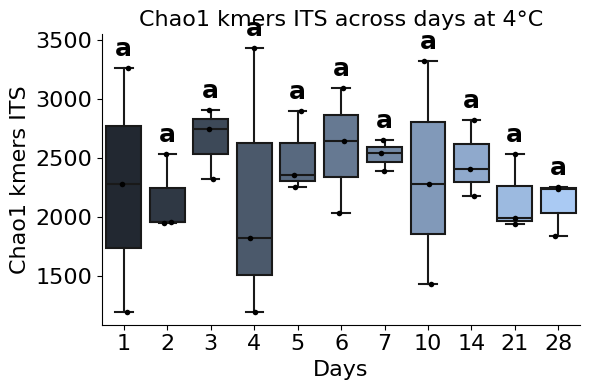

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


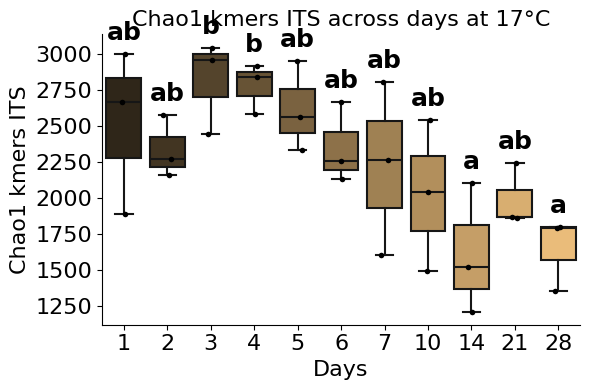

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


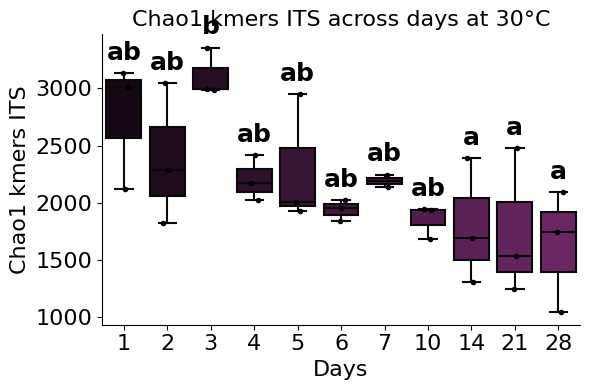

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


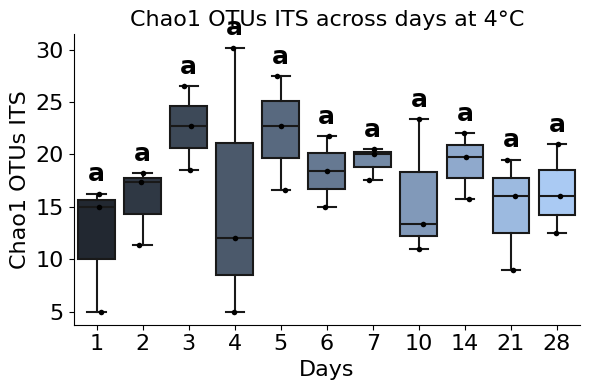

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


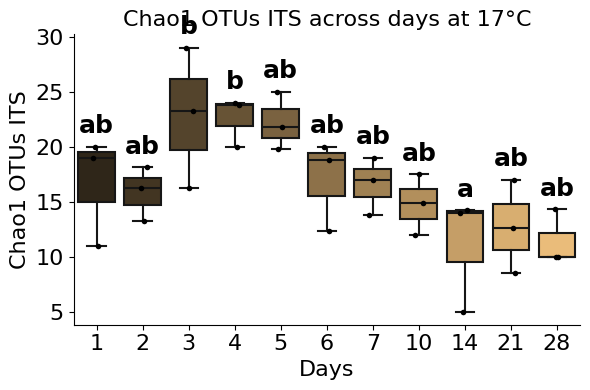

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


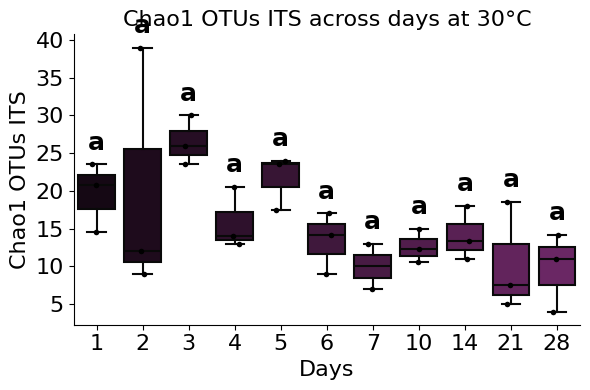

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


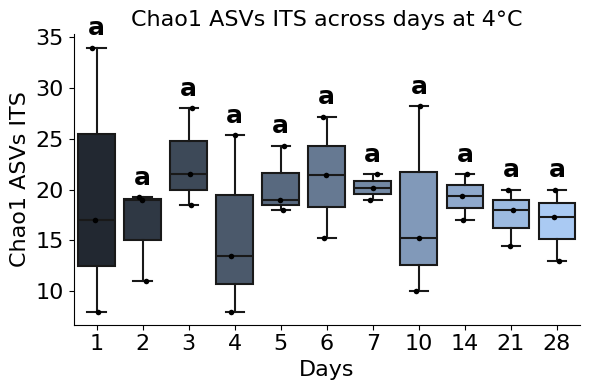

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


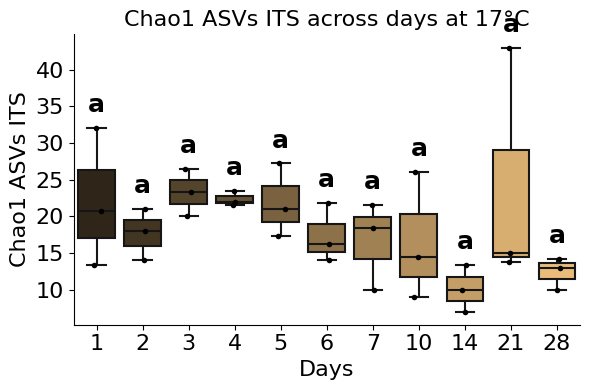

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


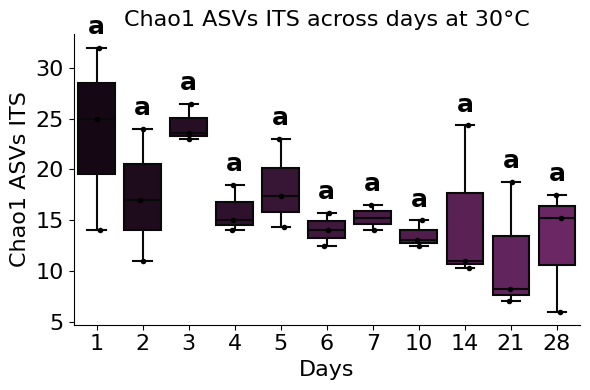

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


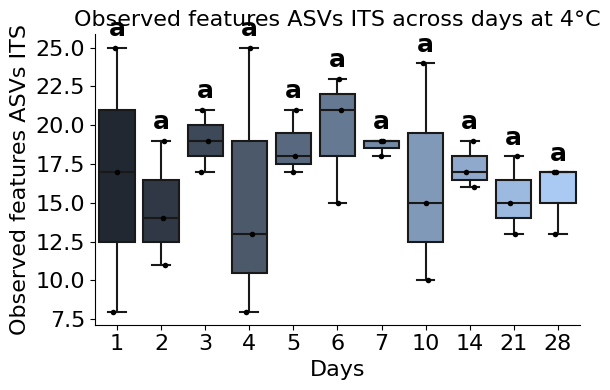

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


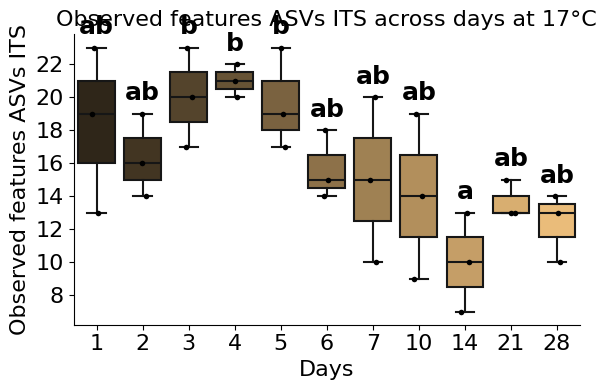

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


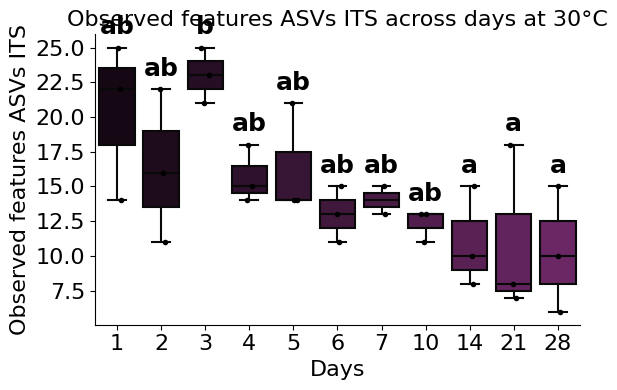

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


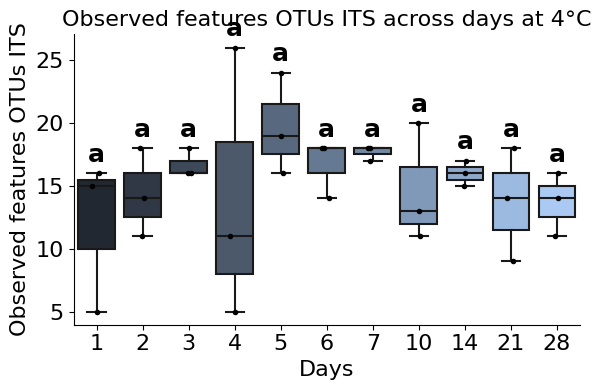

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


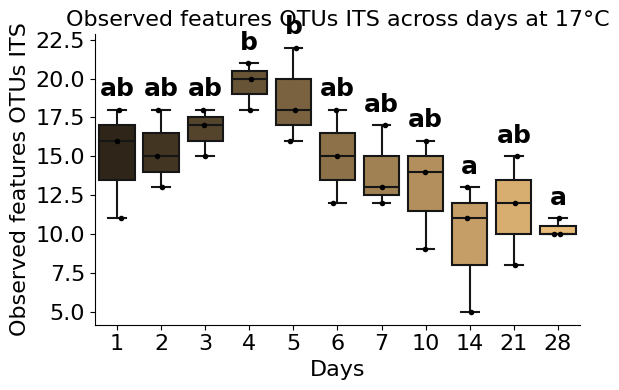

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


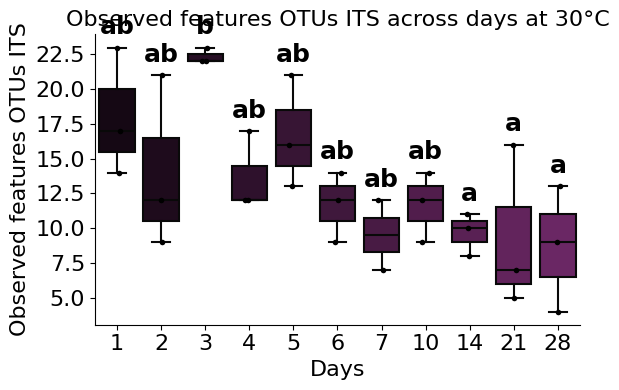

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


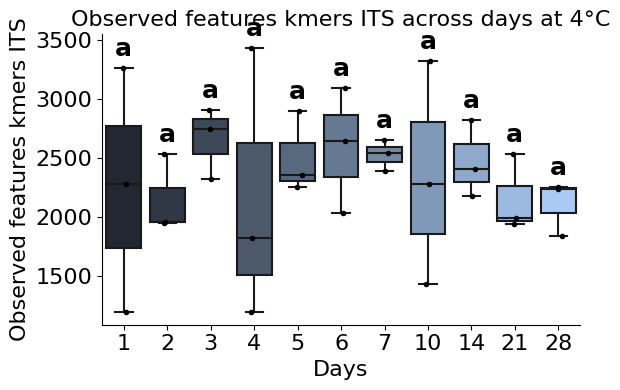

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


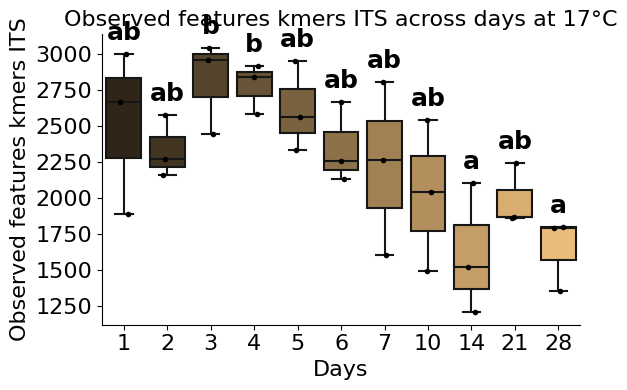

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


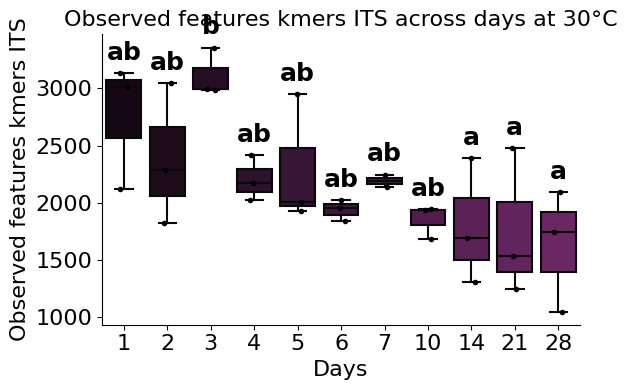

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


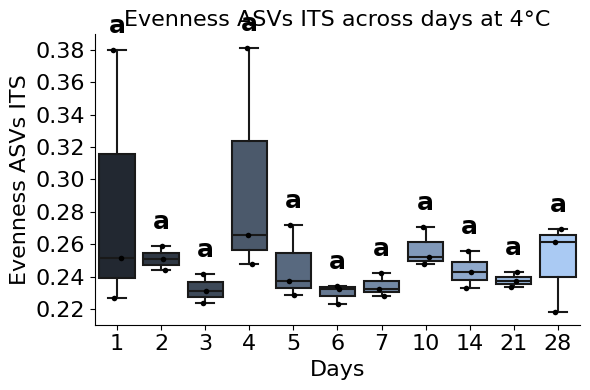

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


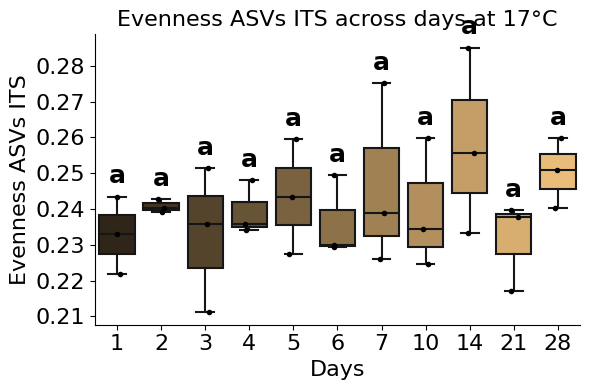

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


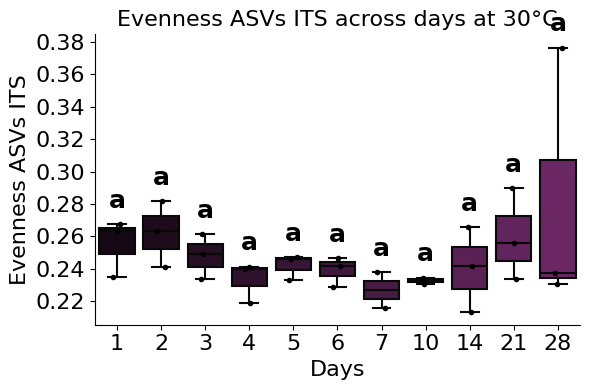

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


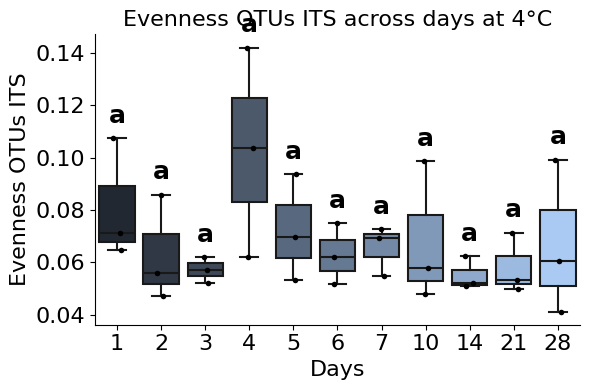

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


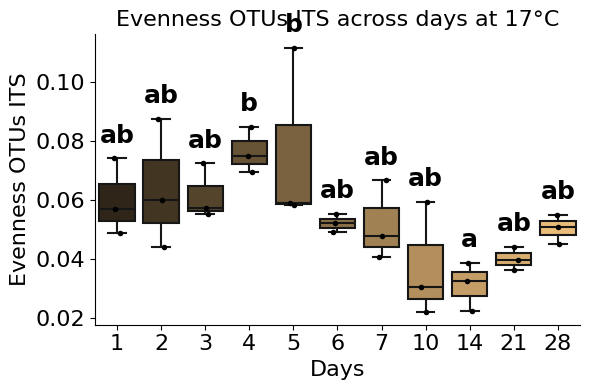

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


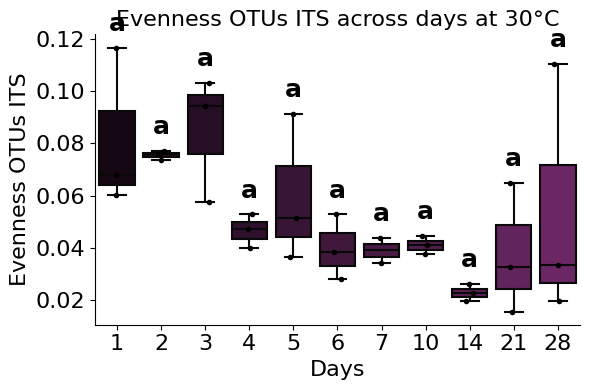

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


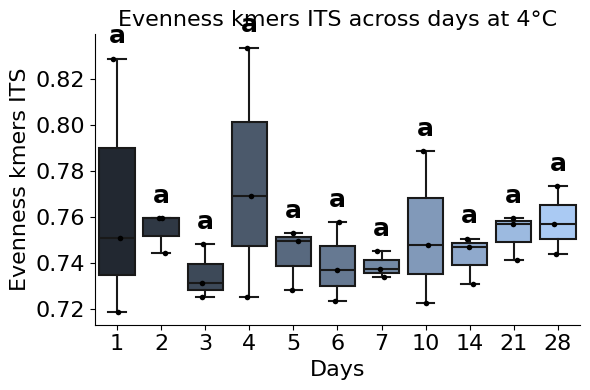

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


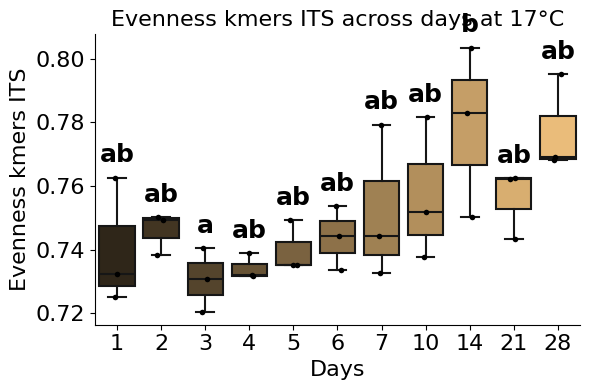

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


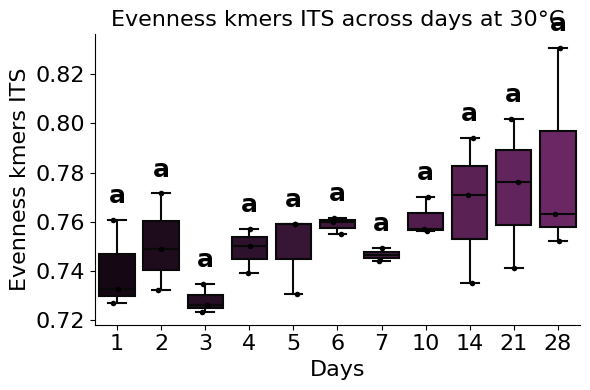

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


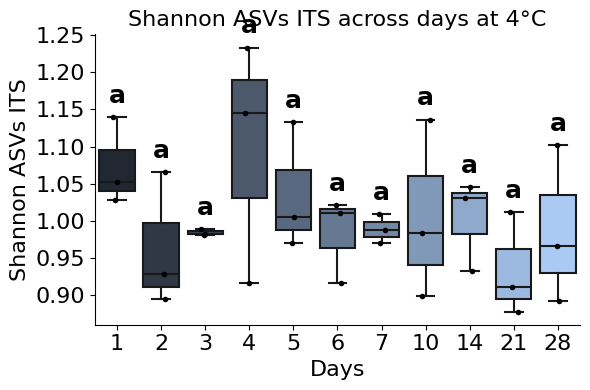

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


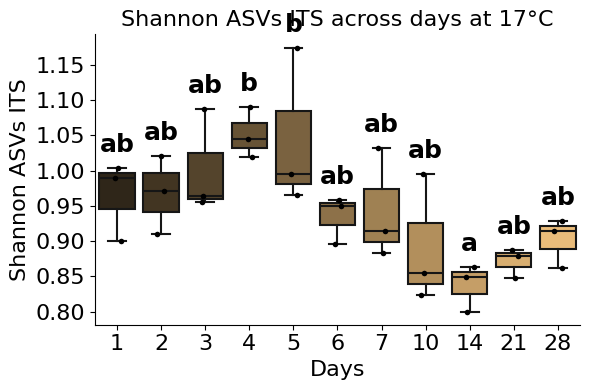

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


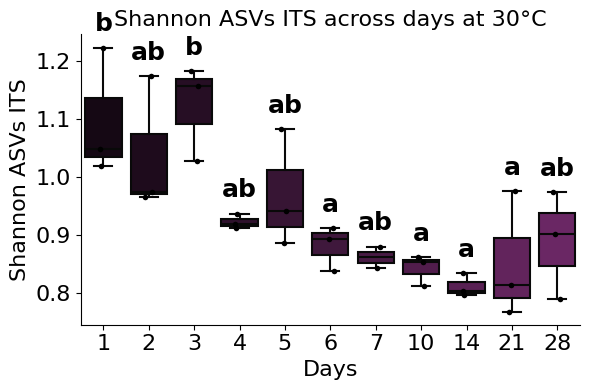

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


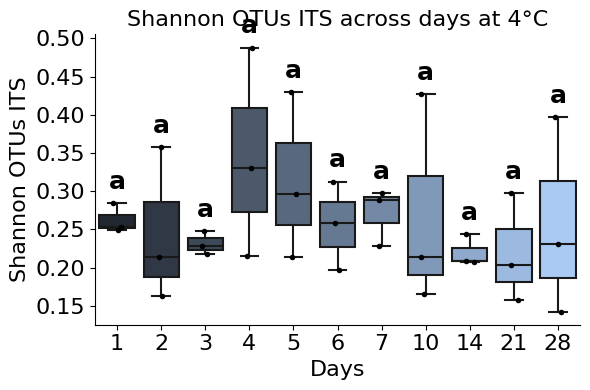

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


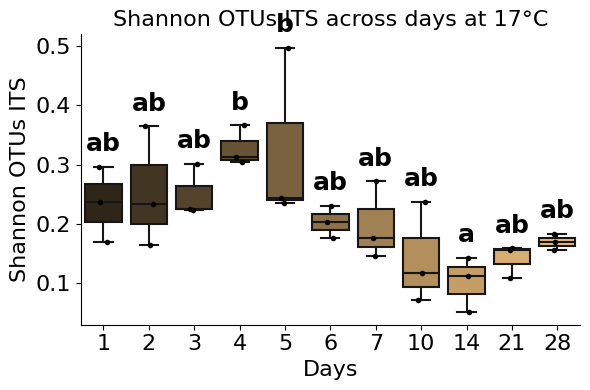

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


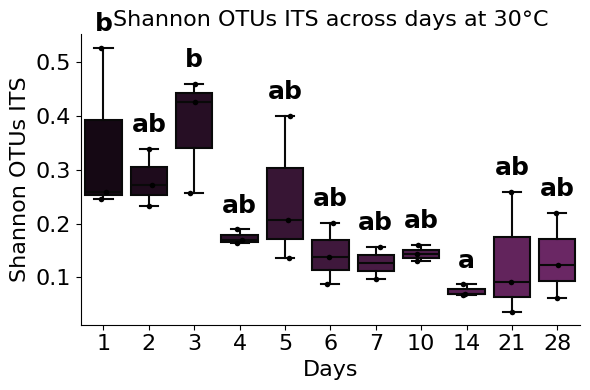

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


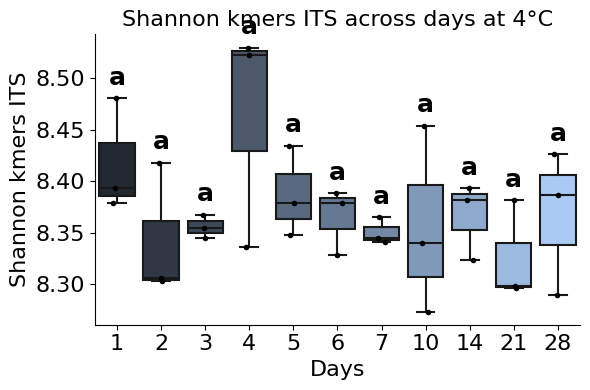

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


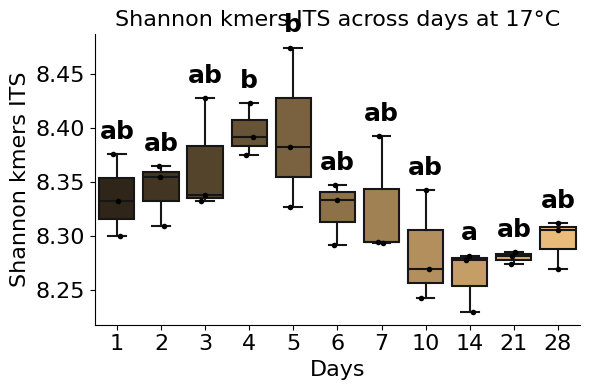

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


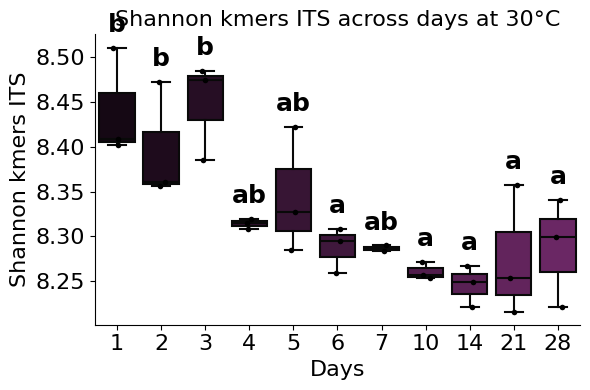

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


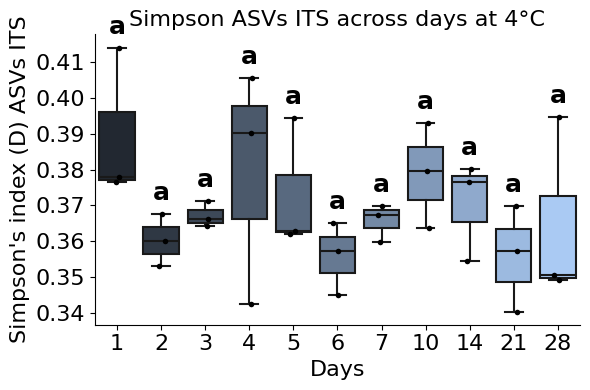

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


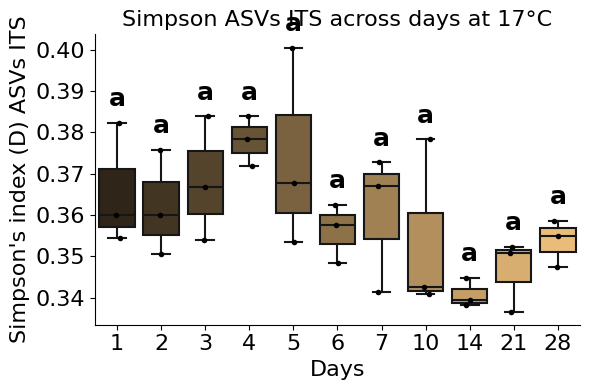

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


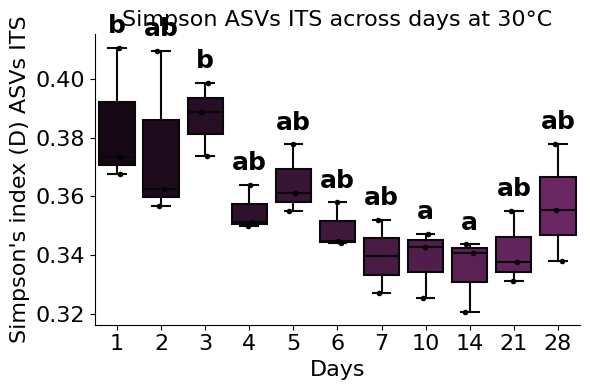

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


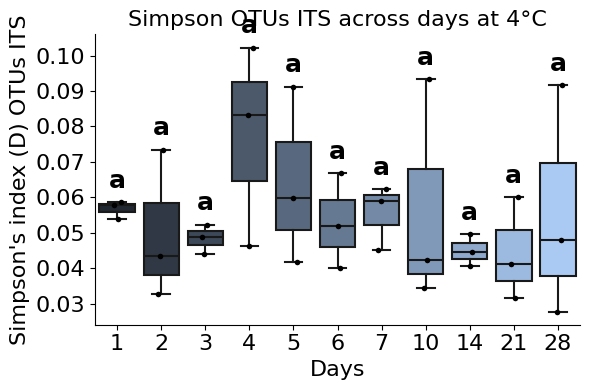

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


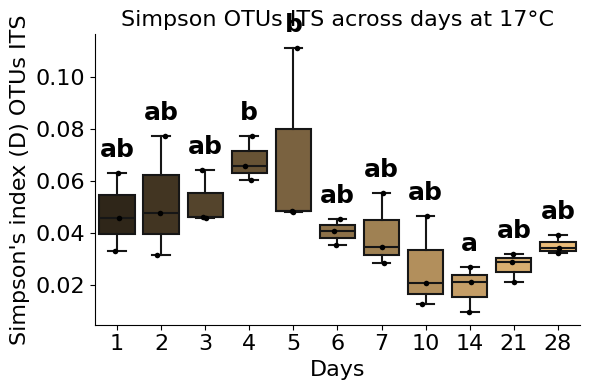

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


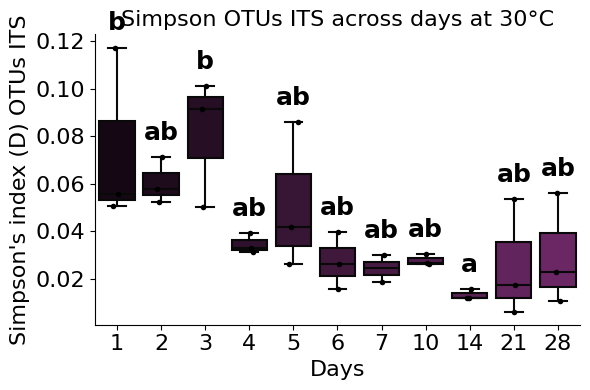

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


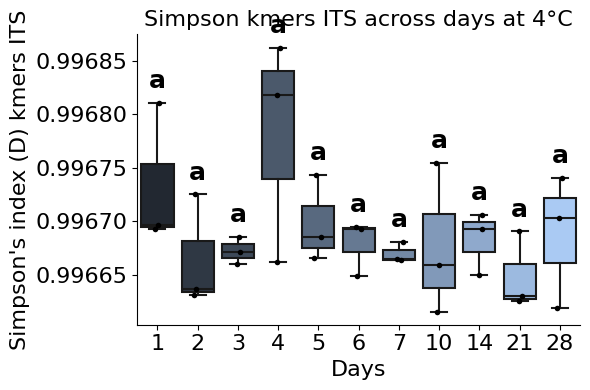

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


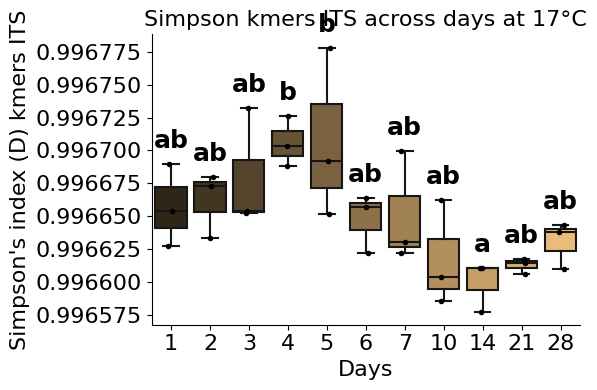

/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/meyeanni/miniconda3/envs/qiime2-amplicon-2024.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


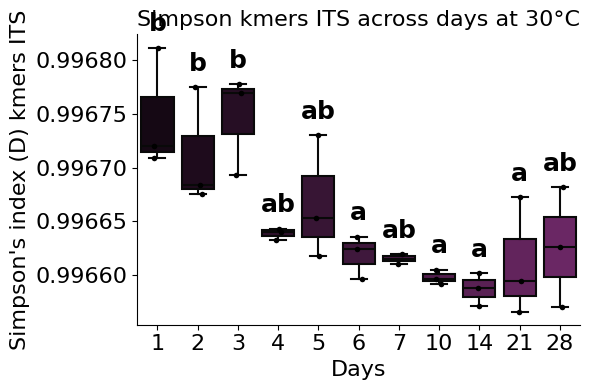

✅ Tukey HSD results exported to: Stats/20251210_tukey_results_all_variables_ITS_all_temperatures.csv


In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Output directory
fig_dir = "Figures/per_variable_stats/"
os.makedirs(fig_dir, exist_ok=True)

# Metrics to analyze
metrics = {
    # 'pH': ('pH', 28),
    # 'TTA': ('TTA', 28),
    # 'LAB CFUs': ('log(CFUs)/g of sourdough', 28),
    # 'yeast CFUs': ('log(CFUs)/g of sourdough', 28),
    # 'estimate_bact': ('bacterial cells', 28),
    # 'DNA yield': ('DNA yield (ng/μL)', 28),
    # 'acetic acid': ('Concentration (mM)', 21),
    # 'glucose': ('Concentration (g/L)', 21),
    # 'fructose': ('Concentration (g/L)', 21),
    # 'sucrose': ('Concentration (g/L)', 21),
    # 'maltose': ('Concentration (g/L)', 21),
    # 'succinic acid': ('Concentration (mM)', 21),
    # 'lactic acid': ('Concentration (mM)', 21),
    # 'ethanol': ('Concentration (mM)', 21),
    'Chao1 kmers ITS': ('Chao1 kmers ITS', 28),
    'Chao1 OTUs ITS': ('Chao1 OTUs ITS', 28),
    'Chao1 ASVs ITS': ('Chao1 ASVs ITS', 28),
    'Observed features ASVs ITS': ('Observed features ASVs ITS', 28),
    'Observed features OTUs ITS': ('Observed features OTUs ITS', 28),
    'Observed features kmers ITS': ('Observed features kmers ITS', 28),
    'Evenness ASVs ITS': ('Evenness ASVs ITS', 28),
    'Evenness OTUs ITS': ('Evenness OTUs ITS', 28),
    'Evenness kmers ITS': ('Evenness kmers ITS', 28),
    'Shannon ASVs ITS': ('Shannon ASVs ITS', 28),
    'Shannon OTUs ITS': ('Shannon OTUs ITS', 28),
    'Shannon kmers ITS': ('Shannon kmers ITS', 28),
    'Simpson ASVs ITS': ("Simpson's index (D) ASVs ITS", 28),
    'Simpson OTUs ITS': ("Simpson's index (D) OTUs ITS", 28),
    'Simpson kmers ITS': ("Simpson's index (D) kmers ITS", 28)
}

# Initialize list to collect all Tukey HSD results
all_tukey_stats = []

# Loop through each variable
for var, (ylab, max_day) in metrics.items():
    for temp in [4, 17, 30]:
        title = f"{var} across days at {temp}°C"
        filename = os.path.join(fig_dir, f"20251210_Tukey_{var.replace(' ', '_')}_{temp}C_ITS.pdf")

        # Plot and get stats
        fig, tukey_stats = plot_days_with_significance_letters(
            data=md,
            value_col=var,
            temperature_value=temp,
            title=title,
            ylabel=ylab,
            colors=md['color'],
            figsize=(6, 4),
            return_stats=True
        )

        # Save figure
        fig.savefig(filename, format='pdf', bbox_inches='tight')
        display(fig)
        plt.close(fig)

        # Add metadata
        tukey_stats['temperature'] = temp
        tukey_stats['variable'] = var
        all_tukey_stats.append(tukey_stats)

# Combine all results
tukey_combined_df = pd.concat(all_tukey_stats, ignore_index=True)

# Export to CSV
csv_path = "Stats/20251210_tukey_results_all_variables_ITS_all_temperatures.csv"
tukey_combined_df.to_csv(csv_path, index=False)
print(f"✅ Tukey HSD results exported to: {csv_path}")